The model is trained in a transductive setting, where message passing uses the full graph structure while supervision is restricted to training nodes only.

# CELLULE 1: MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset"
print(f"✓ Drive monté - Dossier: {folder_path}")

Mounted at /content/drive
✓ Drive monté - Dossier: /content/drive/MyDrive/RT4/SEM2/PFA/elliptic_dataset


#CELLULE 2: INSTALLATION DES DÉPENDANCES

In [ ]:
!pip install torch-geometric -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA disponible: True


# CELLULE 3: IMPORTS

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn.conv import TAGConv

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from torch.nn import BatchNorm1d, Linear, ReLU, Dropout, Sequential


In [ ]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

# Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✓ Imports terminés")

✓ Device: cuda
✓ Imports terminés


# CELLULE 4: CHARGEMENT DES DONNÉES

In [ ]:
df = pd.read_csv(f'{folder_path}/elliptic_clean_features.csv')
edges = pd.read_csv(f'{folder_path}/elliptic_clean_edges.csv')

with open(f'{folder_path}/cleaning_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\n✓ Données chargées:")
print(f"  Transactions (nœuds): {len(df):,}")
print(f"  Edges: {len(edges):,}")

print(f"\n📊 Colonnes disponibles:")
print(f"  Total colonnes: {len(df.columns)}")
print(df.dtypes.value_counts())

print(f"\n📊 Distribution des classes:")
print(df['class_encoded'].value_counts().sort_index())
print("  0 = Licit | 1 = Illicit | 2 = Unknown")


✓ Données chargées:
  Transactions (nœuds): 203,769
  Edges: 234,355

📊 Colonnes disponibles:
  Total colonnes: 187
float64    182
int64        4
object       1
Name: count, dtype: int64

📊 Distribution des classes:
class_encoded
0     42019
1      4545
2    157205
Name: count, dtype: int64
  0 = Licit | 1 = Illicit | 2 = Unknown


# CELLULE 5: PRÉPARATION DES DONNÉES PYTORCH GEOMETRIC

In [ ]:
# ── 5.1 Identifier les features numériques ──────────────────────────────────
numeric_features = [col for col in df.columns
                    if col not in ['txId', 'time_step', 'class_encoded',
                                   'is_labeled', 'split']]

print(f"\n📊 Features disponibles: {len(numeric_features)}")

# S'assurer que toutes les features sont numériques
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_features] = df[numeric_features].fillna(0)

# ── 5.2 Mapping txId → index ────────────────────────────────────────────────
df['txId'] = df['txId'].astype(str)
nodes        = df['txId'].values
map_id       = {tx_id: idx for idx, tx_id in enumerate(nodes)}

print(f"✓ Mapping créé: {len(map_id):,} transactions")

# ── 5.3 Construire edge_index ────────────────────────────────────────────────
print(f"\n🔧 Construction edge_index...")

edges_df = edges.copy()

# Nommer les colonnes si nécessaire
if 'source' not in edges_df.columns:
    edges_df.columns = ['source', 'target'] + list(edges_df.columns[2:])

edges_df['source'] = edges_df['source'].astype(str)
edges_df['target'] = edges_df['target'].astype(str)

# Mapper les IDs
edges_df['source_idx'] = edges_df['source'].map(map_id)
edges_df['target_idx'] = edges_df['target'].map(map_id)

# Supprimer les edges avec nœuds manquants
edges_before = len(edges_df)
edges_df = edges_df.dropna(subset=['source_idx', 'target_idx'])
edges_df = edges_df.astype({'source_idx': int, 'target_idx': int})

if edges_before > len(edges_df):
    print(f"  ⚠ {edges_before - len(edges_df)} edges supprimés (nœuds manquants)")

edge_index = torch.tensor(
    edges_df[['source_idx', 'target_idx']].values.T,
    dtype=torch.long
).contiguous()

weights = torch.ones(edge_index.shape[1], dtype=torch.float32)

print(f"  ✓ Edge index: {edge_index.shape}")

# ── 5.4 Node features ───────────────────────────────────────────────────────
node_features = torch.tensor(
    df[numeric_features].values,
    dtype=torch.float32
)

# Vérification NaN/Inf
if torch.isnan(node_features).any():
    node_features = torch.nan_to_num(node_features, nan=0.0)
if torch.isinf(node_features).any():
    node_features = torch.nan_to_num(node_features, posinf=0.0, neginf=0.0)

print(f"  ✓ Node features: {node_features.shape}")

# ── 5.5 Labels ──────────────────────────────────────────────────────────────
# class_encoded: 0=licit, 1=illicit, 2=unknown
# Pour l'entraînement binaire: unknown → 0 (comme dans le code original)
df['class_binary'] = df['class_encoded'].copy()
df['class_binary'] = df['class_binary'].replace(2, 0)

labels = torch.tensor(df['class_binary'].values, dtype=torch.float32)

print(f"  ✓ Labels tensor: {labels.shape}")
print(f"    Illicit (1): {(labels == 1).sum():,}")
print(f"    Licit/Unknown (0): {(labels == 0).sum():,}")

# ── 5.6 Créer l'objet Data ──────────────────────────────────────────────────
elliptic_dataset = Data(
    x            = node_features,
    edge_index   = edge_index,
    edge_weights = weights,
    y            = labels
)

print(f"\n📊 Dataset PyG:")
print(f"  Nœuds: {elliptic_dataset.num_nodes:,}")
print(f"  Features: {elliptic_dataset.num_features}")
print(f"  Edges: {elliptic_dataset.num_edges:,}")
print(f"  Degré moyen: {elliptic_dataset.num_edges / elliptic_dataset.num_nodes:.2f}")
print(f"  Nœuds isolés: {elliptic_dataset.has_isolated_nodes()}")
print(f"  Self-loops: {elliptic_dataset.has_self_loops()}")
print(f"  Dirigé: {elliptic_dataset.is_directed()}")

# Dimensions pour le modèle
INPUT_DIM = elliptic_dataset.num_features
print(f"\n✓ INPUT_DIM = {INPUT_DIM}")


📊 Features disponibles: 182
✓ Mapping créé: 203,769 transactions

🔧 Construction edge_index...
  ✓ Edge index: torch.Size([2, 234355])
  ✓ Node features: torch.Size([203769, 182])
  ✓ Labels tensor: torch.Size([203769])
    Illicit (1): 4,545
    Licit/Unknown (0): 199,224

📊 Dataset PyG:
  Nœuds: 203,769
  Features: 182
  Edges: 234,355
  Degré moyen: 1.15
  Nœuds isolés: False
  Self-loops: False
  Dirigé: True

✓ INPUT_DIM = 182


# CELLULE 6: SPLIT TRAIN / VAL / TEST

In [ ]:
# ── Indices des nœuds labellisés (illicit ou licit réels, pas unknown) ──────
# is_labeled = 1 → transaction avec label réel (licit ou illicit)
# is_labeled = 0 → unknown
classified_idx   = df.index[df['is_labeled'] == 1].values
unclassified_idx = df.index[df['is_labeled'] == 0].values

y_classified = labels[classified_idx]

print(f"\n📊 Données labellisées: {len(classified_idx):,}")
print(f"  Illicit: {(y_classified == 1).sum():,}")
print(f"  Licit: {(y_classified == 0).sum():,}")
print(f"  Ratio: {(y_classified == 0).sum() / (y_classified == 1).sum():.2f}:1")
print(f"\n📊 Données non-labellisées (test): {len(unclassified_idx):,}")


📊 Données labellisées: 46,564
  Illicit: 4,545
  Licit: 42,019
  Ratio: 9.25:1

📊 Données non-labellisées (test): 157,205


In [ ]:
# ── Split stratifié : 80% train / 20% val ───────────────────────────────────
# Stratifié = maintenir le ratio licit/illicit dans chaque split
_, _, _, _, train_idx, val_idx = train_test_split(
    node_features[classified_idx],
    y_classified,
    classified_idx,
    test_size   = 0.20,       # 20% pour validation
    random_state= SEED,
    stratify    = y_classified
)

elliptic_dataset.train_idx = torch.tensor(train_idx, dtype=torch.long)
elliptic_dataset.val_idx   = torch.tensor(val_idx,   dtype=torch.long)
elliptic_dataset.test_idx  = torch.tensor(unclassified_idx, dtype=torch.long)


In [ ]:
# Vérification de la distribution
y_train = labels[train_idx]
y_val   = labels[val_idx]

print(f"\n📊 Résumé du split:")
print(f"  {'Set':<12} {'Total':>8} {'Illicit':>10} {'Licit':>10} {'Ratio':>10}")
print(f"  {'-'*52}")
print(f"  {'Train':<12} {len(train_idx):>8,} "
      f"{(y_train==1).sum().item():>10,} "
      f"{(y_train==0).sum().item():>10,} "
      f"{(y_train==0).sum().item()/(y_train==1).sum().item():>10.2f}")
print(f"  {'Validation':<12} {len(val_idx):>8,} "
      f"{(y_val==1).sum().item():>10,} "
      f"{(y_val==0).sum().item():>10,} "
      f"{(y_val==0).sum().item()/(y_val==1).sum().item():>10.2f}")
print(f"  {'Test(unkn.)':<12} {len(unclassified_idx):>8,} {'N/A':>10} {'N/A':>10} {'N/A':>10}")

# Vérifier que le ratio est bien préservé
print(f"\n✓ Split stratifié: ratio préservé dans chaque set")


📊 Résumé du split:
  Set             Total    Illicit      Licit      Ratio
  ----------------------------------------------------
  Train          37,251      3,636     33,615       9.25
  Validation      9,313        909      8,404       9.25
  Test(unkn.)   157,205        N/A        N/A        N/A

✓ Split stratifié: ratio préservé dans chaque set


# CELLULE 7: CLASS WEIGHTS (GESTION DU DÉSÉQUILIBRE)

In [ ]:
print("="*60)
print("CALCUL DES CLASS WEIGHTS")
print("="*60)

n_illicit_train = (y_train == 1).sum().item()
n_licit_train   = (y_train == 0).sum().item()
total_train     = n_illicit_train + n_licit_train

# Poids inversement proportionnels
weight_licit   = total_train / (2 * n_licit_train)
weight_illicit = total_train / (2 * n_illicit_train)

print(f"\n⚖️  Class weights:")
print(f"  Licit (0):   {weight_licit:.4f}")
print(f"  Illicit (1): {weight_illicit:.4f}")
print(f"  Ratio poids: {weight_illicit/weight_licit:.2f}x")

pos_weight = torch.tensor([weight_illicit / weight_licit], dtype=torch.float32).to(device)
print(f"\n  pos_weight pour BCEWithLogitsLoss: {pos_weight.item():.4f}")

CALCUL DES CLASS WEIGHTS

⚖️  Class weights:
  Licit (0):   0.5541
  Illicit (1): 5.1225
  Ratio poids: 9.25x

  pos_weight pour BCEWithLogitsLoss: 9.2450


# CELLULE 8: DÉFINITION DU MODÈLE TGNN

In [ ]:
# ── Hyperparamètres ──────────────────────────────────────────────────────────
HIDDEN_SIZE  = 100
OUTPUT_DIM   = 1
K_HOPS       = 3       # Nombre de hops pour TAGConv
LEARNING_RATE = 0.005
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 400
PATIENCE      = 40     # Early stopping

CHECKPOINTS_DIR = './models/elliptic_tgnn'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

In [ ]:
# ============================================================================
# CELLULE 8: DÉFINITION DU MODÈLE TGNN
# ============================================================================
print("="*60)
print("DÉFINITION DU MODÈLE TGNN")
print("="*60)

class TGNN(torch.nn.Module):
    """
    Temporal Graph Neural Network basé sur TAGConv

    Architecture:
    - BatchNorm → TAGConv → BatchNorm → LeakyReLU → TAGConv
    - K hops pour le message passing (exploite homophilie 0.954)
    - BatchNorm pour stabiliser l'entraînement
    """
    def __init__(self, dim_in, dim_h, dim_out, K=3):
        super(TGNN, self).__init__()

        # Normalisation input
        self.norm1 = torch.nn.BatchNorm1d(dim_in)

        # Première couche TAGConv (K hops)
        self.conv1 = TAGConv(dim_in, dim_h, K)

        # Normalisation intermédiaire
        self.norm2 = torch.nn.BatchNorm1d(dim_h)

        # Dropout pour régularisation
        self.dropout = torch.nn.Dropout(p=0.3)

        # Deuxième couche TAGConv
        self.conv2 = TAGConv(dim_h, dim_out, K)

    def forward(self, x, edge_index):
        # Normalisation des features
        h = self.norm1(x)

        # Premier message passing
        h = self.conv1(h, edge_index)

        # Normalisation + activation
        h = self.norm2(h)
        h = F.leaky_relu(h)
        h = self.dropout(h)

        # Deuxième message passing
        out = self.conv2(h, edge_index)

        return out

    def get_embeddings(self, x, edge_index):
        """Retourner les embeddings avant classification"""
        h = self.norm1(x)
        h = self.conv1(h, edge_index)
        h = self.norm2(h)
        h = F.leaky_relu(h)
        return h


# ── Hyperparamètres ──────────────────────────────────────────────────────────
HIDDEN_SIZE  = 100
OUTPUT_DIM   = 1
K_HOPS       = 5       # Nombre de hops pour TAGConv
LEARNING_RATE = 0.005
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 400
PATIENCE      = 40     # Early stopping

CHECKPOINTS_DIR = './models/elliptic_tgnn'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# ── Initialisation ───────────────────────────────────────────────────────────
model = TGNN(INPUT_DIM, HIDDEN_SIZE, OUTPUT_DIM, K_HOPS).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# BCEWithLogitsLoss avec pos_weight pour gérer le déséquilibre
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Modèle TGNN créé:")
print(f"  Input dim:    {INPUT_DIM}")
print(f"  Hidden size:  {HIDDEN_SIZE}")
print(f"  K hops:       {K_HOPS}")
print(f"  Total params: {total_params:,}")
print(f"\n  Architecture:")
print(model)

DÉFINITION DU MODÈLE TGNN
✓ Modèle TGNN créé:
  Input dim:    182
  Hidden size:  100
  K hops:       5
  Total params: 110,465

  Architecture:
TGNN(
  (norm1): BatchNorm1d(182, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): TAGConv(182, 100, K=5)
  (norm2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv2): TAGConv(100, 1, K=5)
)


In [ ]:
# ── Initialisation ───────────────────────────────────────────────────────────
model = TGNN(INPUT_DIM, HIDDEN_SIZE, OUTPUT_DIM, K_HOPS).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# BCEWithLogitsLoss avec pos_weight pour gérer le déséquilibre
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [ ]:
# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Modèle TGNN créé:")
print(f"  Input dim:    {INPUT_DIM}")
print(f"  Hidden size:  {HIDDEN_SIZE}")
print(f"  K hops:       {K_HOPS}")
print(f"  Total params: {total_params:,}")
print(f"\n  Architecture:")
print(model)

✓ Modèle TGNN créé:
  Input dim:    182
  Hidden size:  100
  K hops:       5
  Total params: 110,465

  Architecture:
TGNN(
  (norm1): BatchNorm1d(182, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): TAGConv(182, 100, K=5)
  (norm2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv2): TAGConv(100, 1, K=5)
)


# CELLULE 9: FONCTIONS D'ÉVALUATION COMPLÈTES

In [ ]:
def compute_all_metrics(y_true, y_pred_logits, threshold=0.5):
    """
    Calculer toutes les métriques de performance

    Args:
        y_true: Labels vrais (numpy array)
        y_pred_logits: Logits du modèle (numpy array)
        threshold: Seuil de classification

    Returns:
        dict avec toutes les métriques
    """
    # Probabilités via sigmoid
    y_probs  = torch.sigmoid(torch.tensor(y_pred_logits)).numpy()

    # Labels prédits avec le seuil
    y_pred   = (y_probs > threshold).astype(float)

    metrics = {}

    # ── Métriques de base ────────────────────────────────────────────────────
    metrics['accuracy']  = (y_pred == y_true).mean()
    metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['recall']    = recall_score(y_true, y_pred, zero_division=0)
    metrics['f1']        = f1_score(y_true, y_pred, zero_division=0)

    # ── Métriques basées sur les probabilités ────────────────────────────────
    if len(np.unique(y_true)) > 1:
        metrics['auroc'] = roc_auc_score(y_true, y_probs)
        metrics['auprc'] = average_precision_score(y_true, y_probs)
    else:
        metrics['auroc'] = 0.0
        metrics['auprc'] = 0.0

    # ── Matrice de confusion ─────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics['tn'] = int(tn)
        metrics['fp'] = int(fp)
        metrics['fn'] = int(fn)
        metrics['tp'] = int(tp)
    else:
        metrics['tn'] = metrics['fp'] = metrics['fn'] = metrics['tp'] = 0

    metrics['confusion_matrix'] = cm
    metrics['y_probs']          = y_probs
    metrics['y_pred']           = y_pred

    return metrics


def print_metrics(metrics, set_name="Validation"):
    """Afficher toutes les métriques de manière formatée"""
    print(f"\n{'='*50}")
    print(f"  MÉTRIQUES - {set_name}")
    print(f"{'='*50}")
    print(f"  {'Métrique':<20} {'Valeur':>10}")
    print(f"  {'-'*32}")
    print(f"  {'AUPRC ⭐':<20} {metrics['auprc']:>10.4f}")
    print(f"  {'AUROC':<20} {metrics['auroc']:>10.4f}")
    print(f"  {'F1-Score':<20} {metrics['f1']:>10.4f}")
    print(f"  {'Recall (TPR)':<20} {metrics['recall']:>10.4f}")
    print(f"  {'Precision':<20} {metrics['precision']:>10.4f}")
    print(f"  {'Accuracy':<20} {metrics['accuracy']:>10.4f}")
    print(f"  {'-'*32}")
    print(f"  {'TP':<20} {metrics['tp']:>10,}")
    print(f"  {'FP':<20} {metrics['fp']:>10,}")
    print(f"  {'TN':<20} {metrics['tn']:>10,}")
    print(f"  {'FN':<20} {metrics['fn']:>10,}")
    print(f"{'='*50}")


def accuracy_binary(y_pred_logits, y_true, threshold=0.5):
    """Calculer l'accuracy binaire"""
    y_pred = (torch.sigmoid(y_pred_logits) > threshold).float()
    return (y_pred == y_true).float().mean().item()


print("✓ Fonctions d'évaluation définies")

✓ Fonctions d'évaluation définies


# CELLULE 10: BOUCLE D'ENTRAÎNEMENT

In [ ]:
print("="*60)
print("ENTRAÎNEMENT DU MODÈLE TGNN")
print("="*60)

# Transférer les données vers le device
data_train = elliptic_dataset.to(device)

# Historique
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_auprc':  [], 'val_auroc': [],
    'val_f1':     [], 'val_precision': [], 'val_recall': []
}

best_val_score = 0.0   # F1×0.4 + Recall×0.6
best_val_auprc = 0.0   # suivi pour référence
patience_ctr   = 0
best_epoch     = 0

print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
      f"{'Val Loss':>10} {'Val Acc':>9} "
      f"{'Val F1':>8} {'Val AUPRC':>10} {'Val Recall':>11}")
print("-" * 85)

model.train()

for epoch in range(NUM_EPOCHS):
    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()

    pred = model(data_train.x, data_train.edge_index)

    loss = criterion(
        pred[data_train.train_idx],
        data_train.y[data_train.train_idx].unsqueeze(1)
    )
    train_acc = accuracy_binary(
        pred[data_train.train_idx],
        data_train.y[data_train.train_idx].unsqueeze(1)
    )

    loss.backward()
    optimizer.step()

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        pred_val = model(data_train.x, data_train.edge_index)

        val_loss = criterion(
            pred_val[data_train.val_idx],
            data_train.y[data_train.val_idx].unsqueeze(1)
        ).item()

        val_acc = accuracy_binary(
            pred_val[data_train.val_idx],
            data_train.y[data_train.val_idx].unsqueeze(1)
        )

        y_true_val   = data_train.y[data_train.val_idx].cpu().numpy()
        y_logits_val = pred_val[data_train.val_idx].squeeze(1).cpu().numpy()
        val_metrics  = compute_all_metrics(y_true_val, y_logits_val)

    # ── Historique ───────────────────────────────────────────────────────────
    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auprc'].append(val_metrics['auprc'])
    history['val_auroc'].append(val_metrics['auroc'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])

    # ── Score combiné F1×0.4 + Recall×0.6 ───────────────────────────────────
    val_score = 0.4 * val_metrics['f1'] + 0.6 * val_metrics['recall']

    # ── Early stopping sur le score combiné ──────────────────────────────────
    if val_score > best_val_score:
        best_val_score = val_score
        best_val_auprc = val_metrics['auprc']
        best_epoch     = epoch + 1
        patience_ctr   = 0

        checkpoint = {'state_dict': model.state_dict()}
        torch.save(checkpoint,
                   os.path.join(CHECKPOINTS_DIR, 'tgnn_best_model.pth.tar'))
    else:
        patience_ctr += 1

    # ── Affichage ────────────────────────────────────────────────────────────
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"{epoch+1:>6} {loss.item():>11.4f} {train_acc*100:>9.2f}% "
              f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
              f"{val_metrics['f1']:>8.4f} {val_metrics['auprc']:>10.4f} "
              f"{val_metrics['recall']:>10.4f}")

    # ── Early stopping ────────────────────────────────────────────────────────
    if patience_ctr >= PATIENCE:
        print(f"\n⚠ Early stopping à l'epoch {epoch+1} "
              f"(patience={PATIENCE})")
        break

print(f"\n✓ Entraînement terminé!")
print(f"  Meilleure epoch:                       {best_epoch}")
print(f"  Meilleur score (F1×0.4 + Recall×0.6): {best_val_score:.4f}")
print(f"  AUPRC à cette epoch:                   {best_val_auprc:.4f}")
print(f"  Modèle sauvegardé:  {CHECKPOINTS_DIR}/tgnn_best_model.pth.tar")

ENTRAÎNEMENT DU MODÈLE TGNN

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
-------------------------------------------------------------------------------------
     1      1.3417     61.30%     1.3392    84.16%   0.4808     0.4052     0.7514
    10      0.6193     82.59%     0.6965    82.77%   0.5002     0.6663     0.8834
    20      0.4851     86.48%     0.5848    85.41%   0.5438     0.7652     0.8911
    30      0.4116     89.06%     0.5383    88.39%   0.5980     0.7835     0.8845
    40      0.3678     90.35%     0.5162    90.64%   0.6478     0.8148     0.8823
    50      0.3319     91.80%     0.5105    92.47%   0.6959     0.8466     0.8823
    60      0.3013     92.54%     0.5142    93.24%   0.7182     0.8704     0.8834
    70      0.2769     93.58%     0.4748    93.84%   0.7377     0.8850     0.8878
    80      0.2573     93.95%     0.4663    94.34%   0.7550     0.8944     0.8933
    90      0.2374     94.55%     0.4853    94.68%   0.7666     

# CELLULE 11: ÉVALUATION FINALE DU MEILLEUR MODÈLE


✓ Figure sauvegardée: tgnn_resultats_complets.png


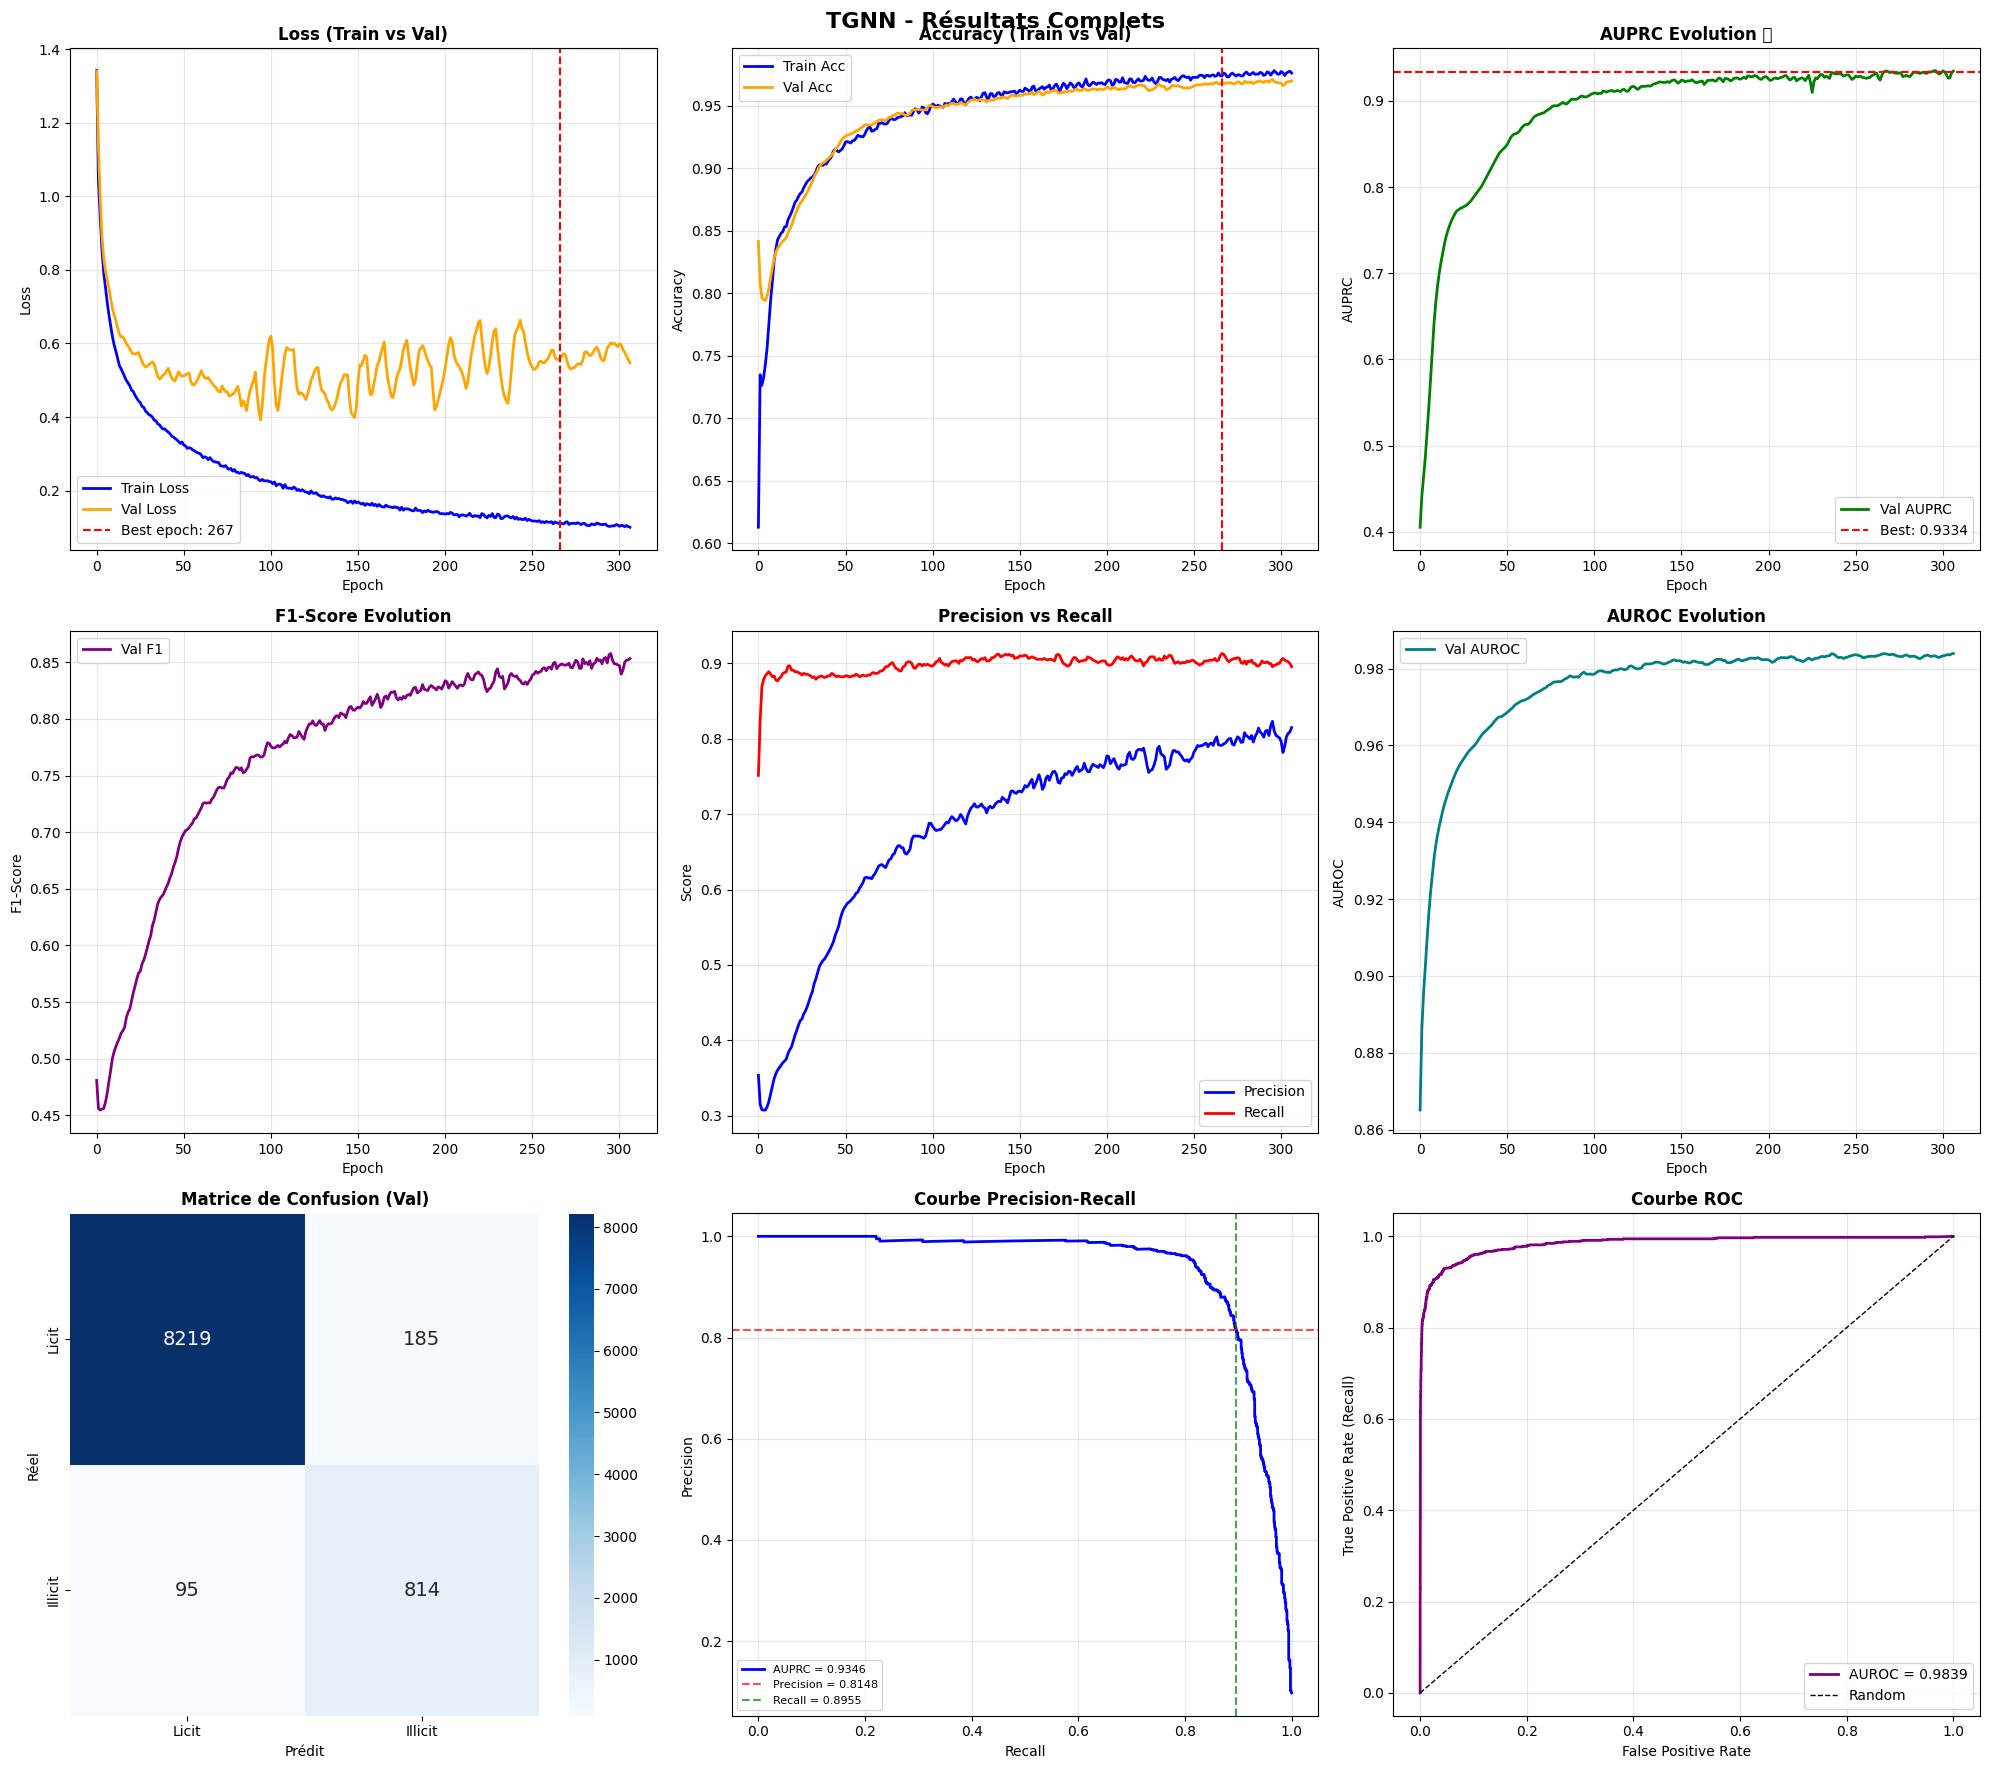

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('TGNN - Résultats Complets', fontsize=16, fontweight='bold')

# ── 1. Train/Val Loss ────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(history['val_loss'],   label='Val Loss',   linewidth=2, color='orange')
ax.axvline(x=best_epoch-1, color='red', linestyle='--',
           label=f'Best epoch: {best_epoch}')
ax.set_title('Loss (Train vs Val)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Train/Val Accuracy ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(history['train_acc'], label='Train Acc', linewidth=2, color='blue')
ax.plot(history['val_acc'],   label='Val Acc',   linewidth=2, color='orange')
ax.axvline(x=best_epoch-1, color='red', linestyle='--')
ax.set_title('Accuracy (Train vs Val)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. AUPRC ─────────────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(history['val_auprc'], label='Val AUPRC', linewidth=2, color='green')
ax.axhline(y=best_val_auprc, color='red', linestyle='--',
           label=f'Best: {best_val_auprc:.4f}')
ax.set_title('AUPRC Evolution ⭐', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUPRC')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 4. F1-Score ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.set_title('F1-Score Evolution', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1-Score')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 5. Precision & Recall ─────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(history['val_precision'], label='Precision', linewidth=2, color='blue')
ax.plot(history['val_recall'],    label='Recall',    linewidth=2, color='red')
ax.set_title('Precision vs Recall', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 6. AUROC ──────────────────────────────────────────────────────────────────
ax = axes[1, 2]
ax.plot(history['val_auroc'], label='Val AUROC', linewidth=2, color='teal')
ax.set_title('AUROC Evolution', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUROC')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
ax = axes[2, 0]
cm = val_metrics['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Licit', 'Illicit'],
            yticklabels=['Licit', 'Illicit'],
            annot_kws={"size": 14})
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de Confusion (Val)', fontweight='bold')

# ── 8. Precision-Recall Curve ─────────────────────────────────────────────────
ax = axes[2, 1]
prec_curve, rec_curve, _ = precision_recall_curve(
    y_true_val, val_metrics['y_probs']
)
ax.plot(rec_curve, prec_curve, linewidth=2, color='blue',
        label=f"AUPRC = {val_metrics['auprc']:.4f}")
ax.axhline(y=val_metrics['precision'], color='r', linestyle='--', alpha=0.7,
           label=f"Precision = {val_metrics['precision']:.4f}")
ax.axvline(x=val_metrics['recall'],    color='g', linestyle='--', alpha=0.7,
           label=f"Recall = {val_metrics['recall']:.4f}")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Courbe Precision-Recall', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 9. ROC Curve ──────────────────────────────────────────────────────────────
ax = axes[2, 2]
fpr, tpr, _ = roc_curve(y_true_val, val_metrics['y_probs'])
ax.plot(fpr, tpr, linewidth=2, color='purple',
        label=f"AUROC = {val_metrics['auroc']:.4f}")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Courbe ROC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tgnn_resultats_complets.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure sauvegardée: tgnn_resultats_complets.png")
plt.show()

# CELLULE 13: RÉSUMÉ FINAL DES MÉTRIQUES

In [ ]:
# ============================================================================
# CELLULE 13: RÉSUMÉ FINAL DES MÉTRIQUES
# ============================================================================
print("="*60)
print("RÉSUMÉ FINAL")
print("="*60)

print(f"\n🏆 MEILLEURS RÉSULTATS (epoch {best_epoch}):")
print(f"\n  {'Métrique':<25} {'Valeur':>10}")
print(f"  {'-'*37}")
print(f"  {'AUPRC (principale) ⭐':<25} {val_metrics['auprc']:>10.4f}")
print(f"  {'AUROC':<25} {val_metrics['auroc']:>10.4f}")
print(f"  {'F1-Score':<25} {val_metrics['f1']:>10.4f}")
print(f"  {'Recall':<25} {val_metrics['recall']:>10.4f}")
print(f"  {'Precision':<25} {val_metrics['precision']:>10.4f}")
print(f"  {'Accuracy':<25} {val_metrics['accuracy']:>10.4f}")

print(f"\n  Détail de la matrice de confusion:")
print(f"  {'TP (Fraudes détectées)':<30} {val_metrics['tp']:>6,}")
print(f"  {'FP (Faux positifs)':<30} {val_metrics['fp']:>6,}")
print(f"  {'TN (Légitimes corrects)':<30} {val_metrics['tn']:>6,}")
print(f"  {'FN (Fraudes manquées)':<30} {val_metrics['fn']:>6,}")

# Interprétation
print(f"\n🎯 INTERPRÉTATION:")
if val_metrics['auprc'] >= 0.80:
    print(f"  🔥 EXCELLENT! AUPRC ≥ 0.80")
    print(f"  → Homophilie de 0.954 parfaitement exploitée")
elif val_metrics['auprc'] >= 0.65:
    print(f"  ✅ TRÈS BON! AUPRC ≥ 0.65")
elif val_metrics['auprc'] >= 0.50:
    print(f"  ⚠️  BON. AUPRC ≥ 0.50")
else:
    print(f"  ❌ À améliorer. AUPRC < 0.50")

# Sauvegarder les résultats
results = {
    'best_epoch': best_epoch,
    'val_metrics': {k: float(v) for k, v in val_metrics.items()
                    if k not in ['confusion_matrix', 'y_probs', 'y_pred']},
    'model_config': {
        'input_dim':    INPUT_DIM,
        'hidden_size':  HIDDEN_SIZE,
        'k_hops':       K_HOPS,
        'learning_rate':LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs':   NUM_EPOCHS,
        'split':        '80/20 stratifié sur données labellisées'
    }
}

with open('tgnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Résultats sauvegardés: tgnn_results.json")

RÉSUMÉ FINAL

🏆 MEILLEURS RÉSULTATS (epoch 267):

  Métrique                      Valeur
  -------------------------------------
  AUPRC (principale) ⭐          0.9346
  AUROC                         0.9839
  F1-Score                      0.8532
  Recall                        0.8955
  Precision                     0.8148
  Accuracy                      0.9699

  Détail de la matrice de confusion:
  TP (Fraudes détectées)            814
  FP (Faux positifs)                185
  TN (Légitimes corrects)         8,219
  FN (Fraudes manquées)              95

🎯 INTERPRÉTATION:
  🔥 EXCELLENT! AUPRC ≥ 0.80
  → Homophilie de 0.954 parfaitement exploitée

✓ Résultats sauvegardés: tgnn_results.json


# CELLULE 14: VISUALISATION t-SNE DES EMBEDDINGS

VISUALISATION t-SNE

🔧 Calcul t-SNE sur 9,313 points...

✓ Figure sauvegardée: tsne_embeddings.png


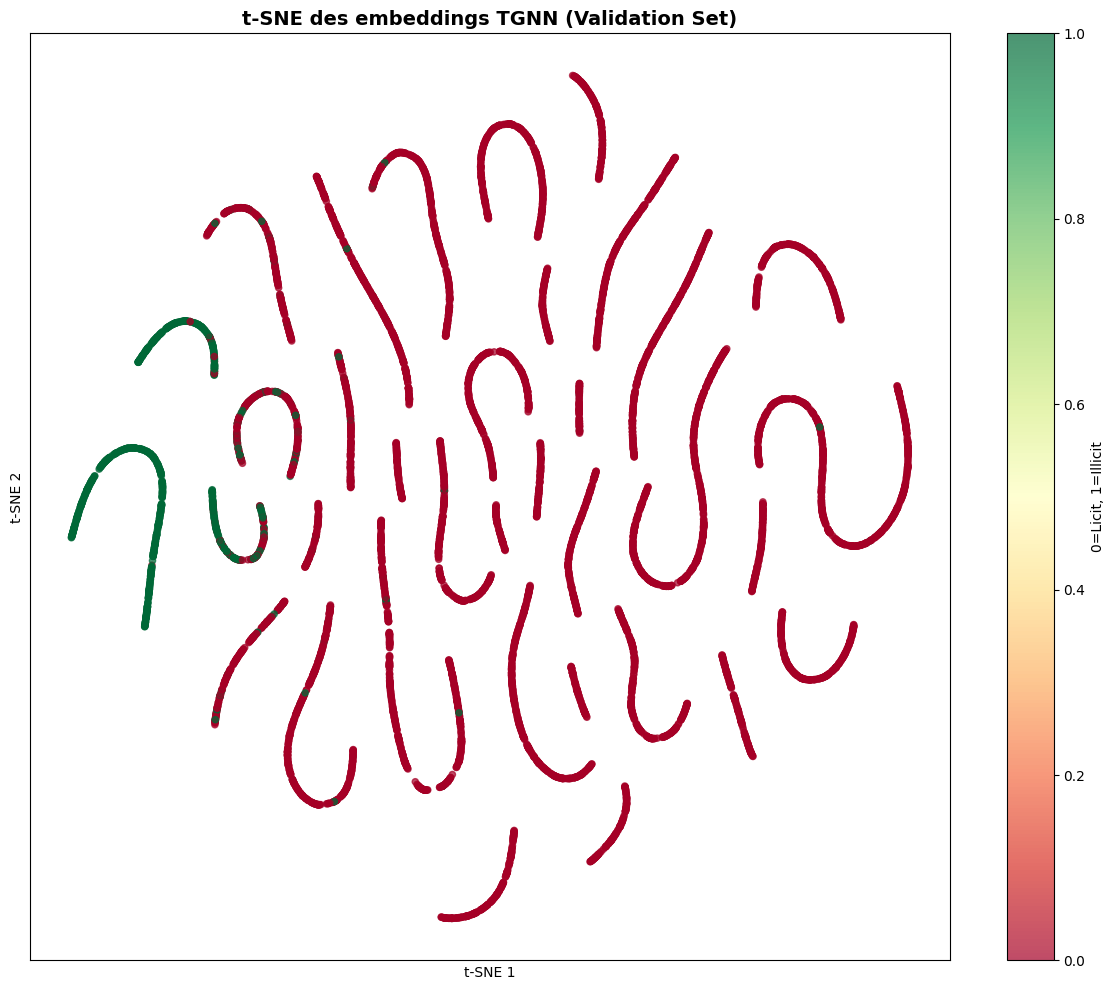

In [ ]:
# ============================================================================
# CELLULE 14: VISUALISATION t-SNE DES EMBEDDINGS
# ============================================================================
print("="*60)
print("VISUALISATION t-SNE")
print("="*60)

model.eval()
with torch.no_grad():
    out_logits = model(data_train.x, data_train.edge_index)

# Préparer pour t-SNE (sur validation uniquement pour rapidité)
out_np = np.array([
    -out_logits.squeeze(1).detach().cpu().numpy(),
     out_logits.squeeze(1).detach().cpu().numpy()
]).T

print(f"\n🔧 Calcul t-SNE sur {len(val_idx):,} points...")

z = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(
    out_np[data_train.val_idx.cpu().numpy()]
)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    z[:, 0], z[:, 1],
    s=20,
    c=data_train.y[data_train.val_idx].cpu().numpy(),
    cmap='RdYlGn',
    alpha=0.7
)
plt.colorbar(scatter, label='0=Licit, 1=Illicit')
plt.title('t-SNE des embeddings TGNN (Validation Set)',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Figure sauvegardée: tsne_embeddings.png")
plt.show()

VISUALISATION t-SNE

🔧 Embeddings shape: (9313, 100)
🔧 Calcul t-SNE sur 9,313 points...

✓ Figure sauvegardée: tsne_embeddings.png


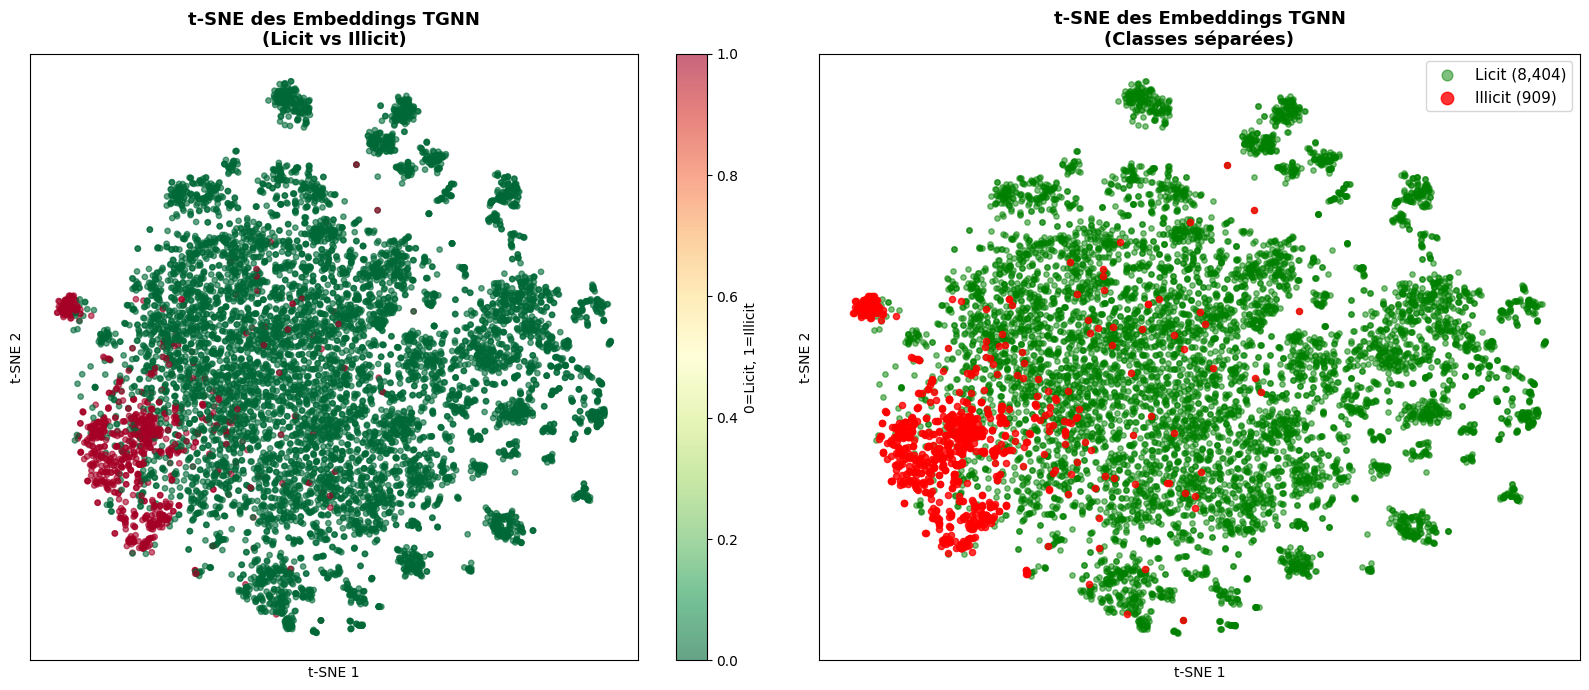

In [ ]:
# ============================================================================
# VISUALISATION t-SNE DES EMBEDDINGS
# ============================================================================
print("="*60)
print("VISUALISATION t-SNE")
print("="*60)

model.eval()
with torch.no_grad():
    # Utiliser les embeddings intermédiaires (avant classification)
    emb = model.get_embeddings(data_train.x, data_train.edge_index)

# Embeddings sur le val set uniquement pour rapidité
emb_val = emb[data_train.val_idx].cpu().numpy()
labels_val = data_train.y[data_train.val_idx].cpu().numpy()

print(f"\n🔧 Embeddings shape: {emb_val.shape}")
print(f"🔧 Calcul t-SNE sur {len(val_idx):,} points...")

z = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED
).fit_transform(emb_val)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot 1: Licit vs Illicit ──────────────────────────────────────────────────
ax1 = axes[0]
colors = ['green' if l == 0 else 'red' for l in labels_val]
scatter = ax1.scatter(
    z[:, 0], z[:, 1],
    s=15,
    c=labels_val,
    cmap='RdYlGn_r',
    alpha=0.6
)
plt.colorbar(scatter, ax=ax1, label='0=Licit, 1=Illicit')
ax1.set_title('t-SNE des Embeddings TGNN\n(Licit vs Illicit)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_xticks([])
ax1.set_yticks([])

# ── Plot 2: Séparé par classe avec légende claire ─────────────────────────────
ax2 = axes[1]

licit_mask   = labels_val == 0
illicit_mask = labels_val == 1

ax2.scatter(z[licit_mask, 0],   z[licit_mask, 1],
            s=15, c='green', alpha=0.5, label=f'Licit ({licit_mask.sum():,})')
ax2.scatter(z[illicit_mask, 0], z[illicit_mask, 1],
            s=20, c='red',   alpha=0.8, label=f'Illicit ({illicit_mask.sum():,})')

ax2.set_title('t-SNE des Embeddings TGNN\n(Classes séparées)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.legend(fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Figure sauvegardée: tsne_embeddings.png")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_val,
    val_metrics['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

              precision    recall  f1-score   support

       licit       0.99      0.98      0.98      8404
     illicit       0.81      0.90      0.85       909

    accuracy                           0.97      9313
   macro avg       0.90      0.94      0.92      9313
weighted avg       0.97      0.97      0.97      9313



# division selon time step

# CELLULE: SPLIT TEMPOREL (OPTION 2)

In [ ]:
print("="*60)
print("SPLIT TEMPOREL (OPTION 2)")
print("="*60)

# ── Définir les frontières temporelles ──────────────────────────────────────
TRAIN_TS = list(range(1, 30))
VAL_TS   = list(range(30, 35))
TEST_TS  = list(range(35, 50))

print(f"\n📊 Frontières temporelles:")
print(f"  Train: timesteps {TRAIN_TS[0]}  → {TRAIN_TS[-1]}  ({len(TRAIN_TS)} steps)")
print(f"  Val:   timesteps {VAL_TS[0]}  → {VAL_TS[-1]}  ({len(VAL_TS)} steps)")
print(f"  Test:  timesteps {TEST_TS[0]}  → {TEST_TS[-1]} ({len(TEST_TS)} steps)")

# ── Créer les masques temporels ──────────────────────────────────────────────
train_mask_ts = df['time_step'].isin(TRAIN_TS)
val_mask_ts   = df['time_step'].isin(VAL_TS)
test_mask_ts  = df['time_step'].isin(TEST_TS)

# ── Indices: labeled uniquement pour train et val ────────────────────────────
train_idx_ts = df.index[train_mask_ts & (df['is_labeled'] == 1)].values
val_idx_ts   = df.index[val_mask_ts   & (df['is_labeled'] == 1)].values


# Test = toutes les transactions dans les timesteps 40-49 (labeled + unknown) on a changer tous est labled
test_idx_ts  = df.index[test_mask_ts].values
#test_idx_ts = df.index[test_mask_ts & (df['is_labeled'] == 1)].values

# ── Statistiques ─────────────────────────────────────────────────────────────
y_train_ts = labels[train_idx_ts]
y_val_ts   = labels[val_idx_ts]
y_test_ts  = labels[test_idx_ts]

print(f"\n📊 Distribution du split temporel:")
print(f"  {'Set':<12} {'Total':>8} {'Illicit':>10} {'Licit':>10} {'Ratio':>10}")
print(f"  {'-'*52}")

for name, idx, y in [
    ('Train',      train_idx_ts, y_train_ts),
    ('Validation', val_idx_ts,   y_val_ts),
    ('Test',       test_idx_ts,  y_test_ts),
]:
    n_ill  = (y == 1).sum().item()
    n_lic  = (y == 0).sum().item()
    ratio  = f"{n_lic/n_ill:.2f}" if n_ill > 0 else "N/A"
    print(f"  {name:<12} {len(idx):>8,} {n_ill:>10,} {n_lic:>10,} {ratio:>10}")

# Assigner au dataset
elliptic_dataset.train_idx = torch.tensor(train_idx_ts, dtype=torch.long)
elliptic_dataset.val_idx   = torch.tensor(val_idx_ts,   dtype=torch.long)
elliptic_dataset.test_idx  = torch.tensor(test_idx_ts,  dtype=torch.long)

print(f"\n✓ Split temporel appliqué au dataset")
print(f"  ⚠ Pas de split aléatoire → respect de l'ordre chronologique")

SPLIT TEMPOREL (OPTION 2)

📊 Frontières temporelles:
  Train: timesteps 1  → 29  (29 steps)
  Val:   timesteps 30  → 34  (5 steps)
  Test:  timesteps 35  → 49 (15 steps)

📊 Distribution du split temporel:
  Set             Total    Illicit      Licit      Ratio
  ----------------------------------------------------
  Train          26,381      2,871     23,510       8.19
  Validation      3,513        591      2,922       4.94
  Test           67,504      1,083     66,421      61.33

✓ Split temporel appliqué au dataset
  ⚠ Pas de split aléatoire → respect de l'ordre chronologique


# CELLULE: CLASS WEIGHTS (RECALCULÉS SUR LE NOUVEAU TRAIN)

In [ ]:
print("="*60)
print("RECALCUL DES CLASS WEIGHTS (SPLIT TEMPOREL)")
print("="*60)

n_illicit_ts = (y_train_ts == 1).sum().item()
n_licit_ts   = (y_train_ts == 0).sum().item()
total_ts     = n_illicit_ts + n_licit_ts

weight_licit_ts   = total_ts / (2 * n_licit_ts)
weight_illicit_ts = total_ts / (2 * n_illicit_ts)

pos_weight_ts = torch.tensor(
    [weight_illicit_ts / weight_licit_ts],
    dtype=torch.float32
).to(device)

print(f"\n⚖️  Class weights (train temporel):")
print(f"  Licit (0):   {weight_licit_ts:.4f}")
print(f"  Illicit (1): {weight_illicit_ts:.4f}")
print(f"  pos_weight:  {pos_weight_ts.item():.4f}")

RECALCUL DES CLASS WEIGHTS (SPLIT TEMPOREL)

⚖️  Class weights (train temporel):
  Licit (0):   0.5611
  Illicit (1): 4.5944
  pos_weight:  8.1888


# CELLULE: ENTRAÎNEMENT AVEC SPLIT TEMPOREL (MÊME ARCHITECTURE)

In [ ]:

# ============================================================================
# CELLULE: ENTRAÎNEMENT AVEC SPLIT TEMPOREL (MÊME ARCHITECTURE)
# ============================================================================
print("="*60)
print("ENTRAÎNEMENT - SPLIT TEMPOREL (MÊME ARCHITECTURE TGNN)")
print("="*60)

# ── Réinitialiser le modèle (même architecture) ──────────────────────────────
torch.manual_seed(SEED)

model_ts = TGNN(INPUT_DIM, HIDDEN_SIZE, OUTPUT_DIM, K_HOPS).to(device)

optimizer_ts = torch.optim.Adam(
    model_ts.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

criterion_ts = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_ts)

CHECKPOINTS_DIR_TS = './models/elliptic_tgnn_temporal'
os.makedirs(CHECKPOINTS_DIR_TS, exist_ok=True)

print(f"\n✓ Modèle réinitialisé (même architecture TGNN)")
print(f"  Input dim:   {INPUT_DIM}")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  K hops:      {K_HOPS}")
print(f"  Early stop:  F1×0.4 + Recall×0.6 (focus détection illicit)")

# ── Historique ───────────────────────────────────────────────────────────────
history_ts = {
    'train_loss': [], 'val_loss':      [],
    'train_acc':  [], 'val_acc':       [],
    'val_auprc':  [], 'val_auroc':     [],
    'val_f1':     [], 'val_precision': [], 'val_recall': []
}

best_val_score_ts = 0.0   # score combiné F1×0.4 + Recall×0.6
best_val_auprc_ts = 0.0   # sauvegardé pour référence
best_epoch_ts     = 0
patience_ctr_ts   = 0

data_train_ts = elliptic_dataset.to(device)

print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
      f"{'Val Loss':>10} {'Val Acc':>9} "
      f"{'Val F1':>8} {'Val AUPRC':>10} {'Val Recall':>11}")
print("-" * 85)

for epoch in range(NUM_EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model_ts.train()
    optimizer_ts.zero_grad()

    pred_ts = model_ts(data_train_ts.x, data_train_ts.edge_index)

    loss_ts = criterion_ts(
        pred_ts[data_train_ts.train_idx],
        data_train_ts.y[data_train_ts.train_idx].unsqueeze(1)
    )
    train_acc_ts = accuracy_binary(
        pred_ts[data_train_ts.train_idx],
        data_train_ts.y[data_train_ts.train_idx].unsqueeze(1)
    )

    loss_ts.backward()
    optimizer_ts.step()

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model_ts.eval()
    with torch.no_grad():
        pred_val_ts = model_ts(data_train_ts.x, data_train_ts.edge_index)

        val_loss_ts = criterion_ts(
            pred_val_ts[data_train_ts.val_idx],
            data_train_ts.y[data_train_ts.val_idx].unsqueeze(1)
        ).item()

        val_acc_ts = accuracy_binary(
            pred_val_ts[data_train_ts.val_idx],
            data_train_ts.y[data_train_ts.val_idx].unsqueeze(1)
        )

        y_true_val_ts   = data_train_ts.y[data_train_ts.val_idx].cpu().numpy()
        y_logits_val_ts = pred_val_ts[data_train_ts.val_idx].squeeze(1).cpu().numpy()
        val_metrics_ts  = compute_all_metrics(y_true_val_ts, y_logits_val_ts)

    # ── Historique ────────────────────────────────────────────────────────────
    history_ts['train_loss'].append(loss_ts.item())
    history_ts['val_loss'].append(val_loss_ts)
    history_ts['train_acc'].append(train_acc_ts)
    history_ts['val_acc'].append(val_acc_ts)
    history_ts['val_auprc'].append(val_metrics_ts['auprc'])
    history_ts['val_auroc'].append(val_metrics_ts['auroc'])
    history_ts['val_f1'].append(val_metrics_ts['f1'])
    history_ts['val_precision'].append(val_metrics_ts['precision'])
    history_ts['val_recall'].append(val_metrics_ts['recall'])

    # ── Score combiné F1 + Recall ─────────────────────────────────────────────
    # Recall pèse plus : rater un illicit (FN) est plus coûteux qu'un faux positif
    val_score = 0.4 * val_metrics_ts['f1'] + 0.6 * val_metrics_ts['recall']

    # ── Early stopping sur le score combiné ───────────────────────────────────
    if val_score > best_val_score_ts:
        best_val_score_ts = val_score
        best_val_auprc_ts = val_metrics_ts['auprc']
        best_epoch_ts     = epoch + 1
        patience_ctr_ts   = 0
        checkpoint = {'state_dict': model_ts.state_dict()}
        torch.save(checkpoint,
                   os.path.join(CHECKPOINTS_DIR_TS, 'tgnn_temporal_best.pth.tar'))
    else:
        patience_ctr_ts += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"{epoch+1:>6} {loss_ts.item():>11.4f} {train_acc_ts*100:>9.2f}% "
              f"{val_loss_ts:>10.4f} {val_acc_ts*100:>8.2f}% "
              f"{val_metrics_ts['f1']:>8.4f} {val_metrics_ts['auprc']:>10.4f} "
              f"{val_metrics_ts['recall']:>10.4f}")

    if patience_ctr_ts >= PATIENCE:
        print(f"\n⚠ Early stopping à l'epoch {epoch+1} "
              f"(patience={PATIENCE})")
        break

print(f"\n✓ Entraînement terminé!")
print(f"  Meilleure epoch:                       {best_epoch_ts}")
print(f"  Meilleur score (F1×0.4 + Recall×0.6): {best_val_score_ts:.4f}")
print(f"  AUPRC à cette epoch:                   {best_val_auprc_ts:.4f}")

ENTRAÎNEMENT - SPLIT TEMPOREL (MÊME ARCHITECTURE TGNN)

✓ Modèle réinitialisé (même architecture TGNN)
  Input dim:   182
  Hidden size: 100
  K hops:      5
  Early stop:  F1×0.4 + Recall×0.6 (focus détection illicit)

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
-------------------------------------------------------------------------------------
     1      1.2249     61.88%     3.4898    78.17%   0.5717     0.5488     0.8663
    10      0.5136     86.03%     1.8194    69.09%   0.5055     0.6772     0.9391
    20      0.3864     89.24%     0.9569    72.42%   0.5379     0.7741     0.9543
    30      0.3248     91.15%     0.8613    74.41%   0.5587     0.7953     0.9628
    40      0.2790     92.56%     0.8610    77.65%   0.5909     0.8191     0.9594
    50      0.2457     93.75%     0.8895    80.05%   0.6150     0.7995     0.9475
    60      0.2194     94.61%     0.9279    81.92%   0.6361     0.8051     0.9391
    70      0.1967     95.33%     0.8

# CELLULE: PRÉDICTIONS SUR LE TEST SET (TEMPORAL SPLIT ts 40-49)

In [ ]:
# ============================================================================
# CELLULE: PRÉDICTIONS SUR LE TEST SET (TEMPORAL SPLIT ts 40-49)
# ============================================================================
print("="*60)
print("PRÉDICTIONS SUR LE TEST SET (timesteps 40-49)")
print("="*60)

# Charger le meilleur modèle temporel
model_ts.load_state_dict(
    torch.load(os.path.join(CHECKPOINTS_DIR_TS, 'tgnn_temporal_best.pth.tar'))['state_dict']
)
model_ts.eval()

with torch.no_grad():
    pred_test_ts = model_ts(data_train_ts.x, data_train_ts.edge_index)

# ── Séparer labeled vs unknown dans le test set ──────────────────────────────
test_idx_all      = data_train_ts.test_idx.cpu().numpy()
test_labeled_mask = df.loc[test_idx_all, 'is_labeled'].values == 1

test_labeled_idx   = test_idx_all[test_labeled_mask]
test_unlabeled_idx = test_idx_all[~test_labeled_mask]

print(f"\n📊 Composition du test set (ts 40-49):")
print(f"  Total transactions:     {len(test_idx_all):,}")
print(f"  Avec label (évaluables): {len(test_labeled_idx):,}")
print(f"  Sans label (unknown):    {len(test_unlabeled_idx):,}")

PRÉDICTIONS SUR LE TEST SET (timesteps 40-49)

📊 Composition du test set (ts 40-49):
  Total transactions:     67,504
  Avec label (évaluables): 16,670
  Sans label (unknown):    50,834


# CELLULE: MÉTRIQUES SUR LES DONNÉES LABELLISÉES DU TEST SET

In [ ]:
# ============================================================================
# CELLULE: MÉTRIQUES SUR LES DONNÉES LABELLISÉES DU TEST SET
# ============================================================================
print("="*60)
print("MÉTRIQUES TEST SET - DONNÉES LABELLISÉES")
print("="*60)

# Récupérer les vrais labels et logits pour les nœuds labellisés du test
y_true_test   = data_train_ts.y[test_labeled_idx].cpu().numpy()
y_logits_test = pred_test_ts[test_labeled_idx].squeeze(1).cpu().numpy()

# Calculer toutes les métriques
test_metrics_ts = compute_all_metrics(y_true_test, y_logits_test)

# ── Distribution des classes dans le test set ─────────────────────────────────
n_ill_test = (y_true_test == 1).sum()
n_lic_test = (y_true_test == 0).sum()

print(f"\n📊 Distribution test set (labeled):")
print(f"  Illicit: {n_ill_test:,} ({n_ill_test/len(y_true_test)*100:.1f}%)")
print(f"  Licit:   {n_lic_test:,} ({n_lic_test/len(y_true_test)*100:.1f}%)")

# ── Affichage des métriques ───────────────────────────────────────────────────
print_metrics(test_metrics_ts, "TEST SET (ts 40-49)")

# ── Classification Report ─────────────────────────────────────────────────────
print(f"\n📊 CLASSIFICATION REPORT - Test Set:")
print(classification_report(
    y_true_test,
    test_metrics_ts['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

MÉTRIQUES TEST SET - DONNÉES LABELLISÉES

📊 Distribution test set (labeled):
  Illicit: 1,083 (6.5%)
  Licit:   15,587 (93.5%)

  MÉTRIQUES - TEST SET (ts 40-49)
  Métrique                 Valeur
  --------------------------------
  AUPRC ⭐                  0.4038
  AUROC                    0.8857
  F1-Score                 0.3308
  Recall (TPR)             0.7932
  Precision                0.2090
  Accuracy                 0.7915
  --------------------------------
  TP                          859
  FP                        3,251
  TN                       12,336
  FN                          224

📊 CLASSIFICATION REPORT - Test Set:
              precision    recall  f1-score   support

       licit       0.98      0.79      0.88     15587
     illicit       0.21      0.79      0.33      1083

    accuracy                           0.79     16670
   macro avg       0.60      0.79      0.60     16670
weighted avg       0.93      0.79      0.84     16670



In [ ]:
# ============================================================================
# CELLULE: COMPARAISON VAL vs TEST (TEMPORAL SPLIT)
# ============================================================================
print("="*60)
print("COMPARAISON: VALIDATION vs TEST (TEMPORAL SPLIT)")
print("="*60)

print(f"\n  {'Métrique':<22} {'Val (ts 35-39)':>16} {'Test (ts 40-49)':>16} {'Δ':>8}")
print(f"  {'-'*64}")

metriques = [
    ('AUPRC ⭐',  'auprc'),
    ('AUROC',     'auroc'),
    ('F1-Score',  'f1'),
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('Accuracy',  'accuracy'),
]

for label, key in metriques:
    v_val  = val_metrics_ts[key]
    v_test = test_metrics_ts[key]
    delta  = v_test - v_val
    arrow  = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {label:<22} {v_val:>16.4f} {v_test:>16.4f} "
          f"{arrow}{abs(delta):>6.4f}")

print(f"\n  {'Support':<22} {len(y_true_val_ts):>16,} {len(y_true_test):>16,}")

COMPARAISON: VALIDATION vs TEST (TEMPORAL SPLIT)

  Métrique                 Val (ts 35-39)  Test (ts 40-49)        Δ
  ----------------------------------------------------------------
  AUPRC ⭐                          0.8249           0.4038 ↓0.4211
  AUROC                            0.9568           0.8857 ↓0.0711
  F1-Score                         0.7363           0.3308 ↓0.4054
  Recall                           0.9188           0.7932 ↓0.1256
  Precision                        0.6143           0.2090 ↓0.4053
  Accuracy                         0.8893           0.7915 ↓0.0977

  Support                           3,513           16,670


✓ Figure sauvegardée: test_results_temporal.png


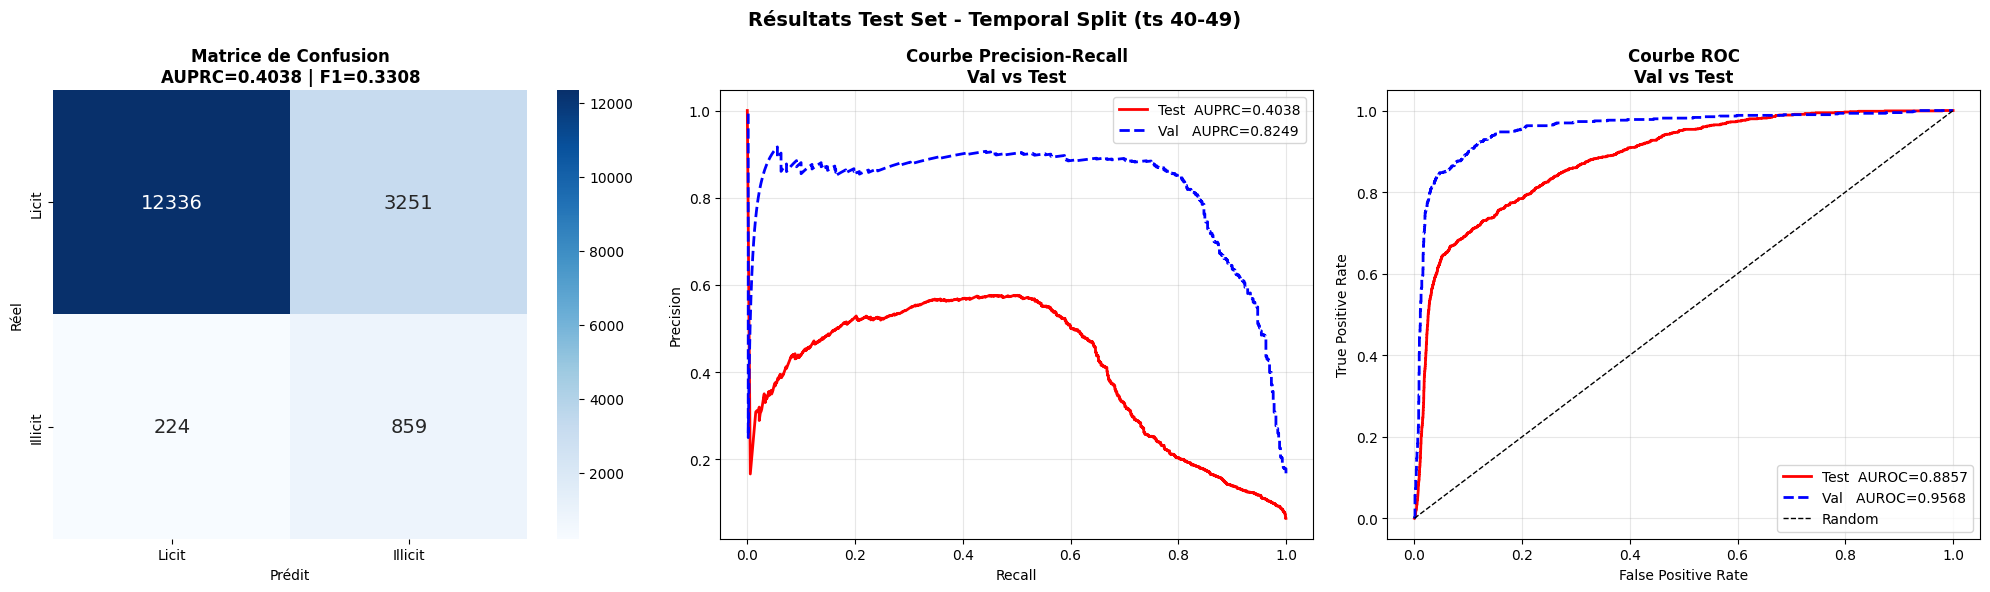

In [ ]:
# ============================================================================
# CELLULE: VISUALISATIONS TEST SET
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Résultats Test Set - Temporal Split (ts 40-49)',
             fontsize=14, fontweight='bold')

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
ax1 = axes[0]
sns.heatmap(
    test_metrics_ts['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues', ax=ax1,
    xticklabels=['Licit', 'Illicit'],
    yticklabels=['Licit', 'Illicit'],
    annot_kws={"size": 14}
)
ax1.set_title(f"Matrice de Confusion\nAUPRC={test_metrics_ts['auprc']:.4f} "
              f"| F1={test_metrics_ts['f1']:.4f}",
              fontweight='bold')
ax1.set_xlabel('Prédit')
ax1.set_ylabel('Réel')

# ── 2. Precision-Recall Curve ─────────────────────────────────────────────────
ax2 = axes[1]
prec_curve, rec_curve, _ = precision_recall_curve(
    y_true_test, test_metrics_ts['y_probs']
)
# Ajouter aussi la courbe validation pour comparaison
prec_val_curve, rec_val_curve, _ = precision_recall_curve(
    y_true_val_ts, val_metrics_ts['y_probs']
)

ax2.plot(rec_curve,     prec_curve,     linewidth=2, color='red',
         label=f"Test  AUPRC={test_metrics_ts['auprc']:.4f}")
ax2.plot(rec_val_curve, prec_val_curve, linewidth=2, color='blue',
         linestyle='--', label=f"Val   AUPRC={val_metrics_ts['auprc']:.4f}")
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Courbe Precision-Recall\nVal vs Test', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── 3. ROC Curve ──────────────────────────────────────────────────────────────
ax3 = axes[2]
fpr_test, tpr_test, _ = roc_curve(y_true_test,    test_metrics_ts['y_probs'])
fpr_val,  tpr_val,  _ = roc_curve(y_true_val_ts,  val_metrics_ts['y_probs'])

ax3.plot(fpr_test, tpr_test, linewidth=2, color='red',
         label=f"Test  AUROC={test_metrics_ts['auroc']:.4f}")
ax3.plot(fpr_val,  tpr_val,  linewidth=2, color='blue',
         linestyle='--', label=f"Val   AUROC={val_metrics_ts['auroc']:.4f}")
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Courbe ROC\nVal vs Test', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_results_temporal.png', dpi=300, bbox_inches='tight')
print("✓ Figure sauvegardée: test_results_temporal.png")
plt.show()

In [ ]:
# ============================================================================
# CELLULE: RÉSUMÉ FINAL COMPLET
# ============================================================================
print("="*60)
print("RÉSUMÉ FINAL - TEMPORAL SPLIT")
print("="*60)

print(f"\n  Modèle: TGNN (TAGConv, K={K_HOPS}, hidden={HIDDEN_SIZE})")
print(f"  Split:  Train ts 1-34 | Val ts 35-39 | Test ts 40-49")

print(f"\n  {'Métrique':<22} {'Train*':>10} {'Val':>10} {'Test':>10}")
print(f"  {'-'*54}")

# Train metrics
model_ts.eval()
with torch.no_grad():
    pred_all = model_ts(data_train_ts.x, data_train_ts.edge_index)

y_true_train   = data_train_ts.y[data_train_ts.train_idx].cpu().numpy()
y_logits_train = pred_all[data_train_ts.train_idx].squeeze(1).cpu().numpy()
train_metrics_ts = compute_all_metrics(y_true_train, y_logits_train)

for label, key in metriques:
    v_tr   = train_metrics_ts[key]
    v_val  = val_metrics_ts[key]
    v_test = test_metrics_ts[key]
    print(f"  {label:<22} {v_tr:>10.4f} {v_val:>10.4f} {v_test:>10.4f}")

print(f"\n  {'Support':<22} {len(y_true_train):>10,} "
      f"{len(y_true_val_ts):>10,} {len(y_true_test):>10,}")

print(f"\n  * Train metrics calculées sur les données d'entraînement")
print(f"\n🎯 INTERPRÉTATION TEST SET:")
if test_metrics_ts['auprc'] >= 0.80:
    print(f"  🔥 EXCELLENT! AUPRC = {test_metrics_ts['auprc']:.4f} (≥ 0.80)")
elif test_metrics_ts['auprc'] >= 0.65:
    print(f"  ✅ TRÈS BON! AUPRC = {test_metrics_ts['auprc']:.4f} (≥ 0.65)")
elif test_metrics_ts['auprc'] >= 0.50:
    print(f"  ⚠️  BON.   AUPRC = {test_metrics_ts['auprc']:.4f} (≥ 0.50)")
else:
    print(f"  ❌ À améliorer. AUPRC = {test_metrics_ts['auprc']:.4f} (< 0.50)")

RÉSUMÉ FINAL - TEMPORAL SPLIT

  Modèle: TGNN (TAGConv, K=5, hidden=100)
  Split:  Train ts 1-34 | Val ts 35-39 | Test ts 40-49

  Métrique                   Train*        Val       Test
  ------------------------------------------------------
  AUPRC ⭐                    0.9832     0.8249     0.4038
  AUROC                      0.9979     0.9568     0.8857
  F1-Score                   0.8879     0.7363     0.3308
  Recall                     0.9854     0.9188     0.7932
  Precision                  0.8081     0.6143     0.2090
  Accuracy                   0.9729     0.8893     0.7915

  Support                    26,381      3,513     16,670

  * Train metrics calculées sur les données d'entraînement

🎯 INTERPRÉTATION TEST SET:
  ❌ À améliorer. AUPRC = 0.4038 (< 0.50)


ANALYSE PAR TIMESTEP (ts 40-49)

    TS   Total  Illicit   Licit    AUPRC      F1   Recall    Prec
  -----------------------------------------------------------------
    35   1,341      182   1,159   0.8380  0.6370   0.9451  0.4804
    36   1,708       33   1,675   0.3652  0.1928   0.9697  0.1070
    37     498       40     458   0.7222  0.4722   0.8500  0.3269
    38     756      111     645   0.8608  0.5833   0.9459  0.4217
    39   1,183       81   1,102   0.7410  0.3861   0.9630  0.2415
    40   1,211      112   1,099   0.5629  0.3730   0.8125  0.2420
    41   1,132      116   1,016   0.5623  0.3636   0.8103  0.2344
    42   2,154      239   1,915   0.5948  0.4668   0.8536  0.3213
    43   1,370       24   1,346   0.0165  0.0225   0.2083  0.0119
    44   1,591       24   1,567   0.0370  0.0249   0.2083  0.0132
    45   1,221        5   1,216   0.0160  0.0390   0.6000  0.0201
    46     712        2     710   0.2603  0.0260   1.0000  0.0132
    47     846       22     824   0.0459 

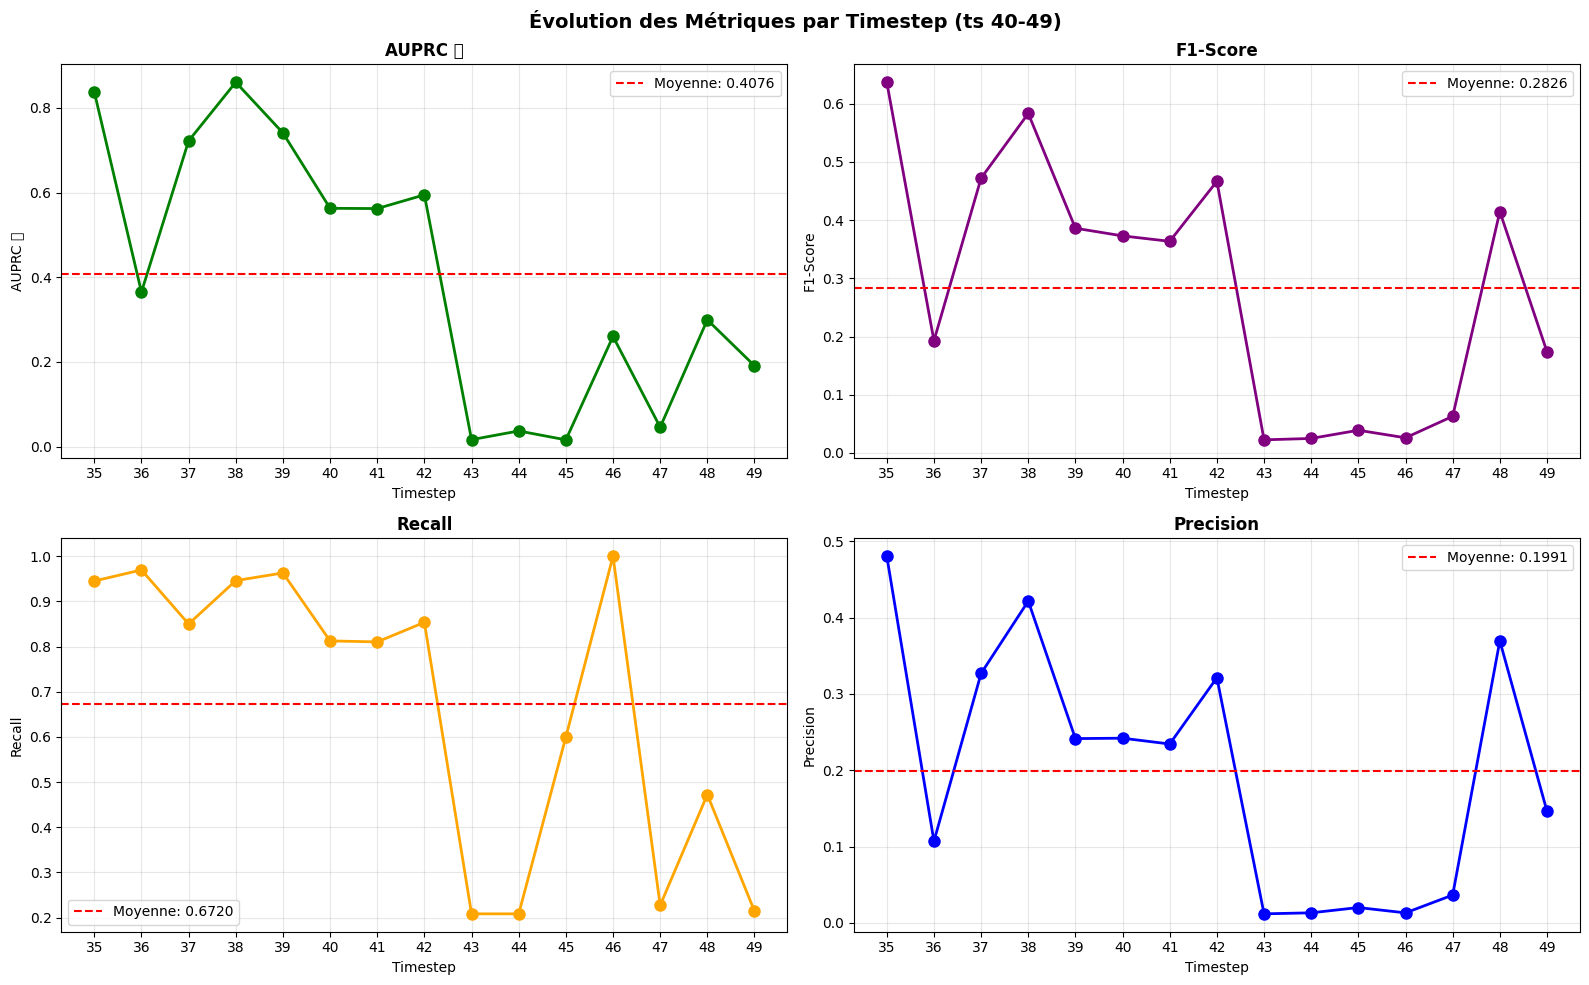

In [ ]:
# ============================================================================
# CELLULE: ANALYSE PAR TIMESTEP (ÉVOLUTION DES MÉTRIQUES)
# ============================================================================
print("="*60)
print("ANALYSE PAR TIMESTEP (ts 40-49)")
print("="*60)

ts_results = []

for ts in TEST_TS:
    # Indices du timestep courant (labeled uniquement)
    ts_idx = df.index[
        (df['time_step'] == ts) & (df['is_labeled'] == 1)
    ].values

    if len(ts_idx) == 0:
        continue

    y_true_ts_step   = data_train_ts.y[ts_idx].cpu().numpy()
    y_logits_ts_step = pred_test_ts[ts_idx].squeeze(1).cpu().numpy()

    # Ignorer si une seule classe présente
    if len(np.unique(y_true_ts_step)) < 2:
        continue

    m = compute_all_metrics(y_true_ts_step, y_logits_ts_step)

    n_ill = (y_true_ts_step == 1).sum()
    n_lic = (y_true_ts_step == 0).sum()

    ts_results.append({
        'timestep':  ts,
        'n_total':   len(ts_idx),
        'n_illicit': n_ill,
        'n_licit':   n_lic,
        'auprc':     m['auprc'],
        'auroc':     m['auroc'],
        'f1':        m['f1'],
        'recall':    m['recall'],
        'precision': m['precision'],
        'accuracy':  m['accuracy'],
    })

ts_df = pd.DataFrame(ts_results)

# ── Affichage tableau ─────────────────────────────────────────────────────────
print(f"\n  {'TS':>4} {'Total':>7} {'Illicit':>8} {'Licit':>7} "
      f"{'AUPRC':>8} {'F1':>7} {'Recall':>8} {'Prec':>7}")
print(f"  {'-'*65}")

for _, row in ts_df.iterrows():
    print(f"  {int(row['timestep']):>4} {int(row['n_total']):>7,} "
          f"{int(row['n_illicit']):>8,} {int(row['n_licit']):>7,} "
          f"{row['auprc']:>8.4f} {row['f1']:>7.4f} "
          f"{row['recall']:>8.4f} {row['precision']:>7.4f}")

print(f"\n  {'MEAN':>4} {ts_df['n_total'].mean():>7.0f} "
      f"{ts_df['n_illicit'].mean():>8.0f} {ts_df['n_licit'].mean():>7.0f} "
      f"{ts_df['auprc'].mean():>8.4f} {ts_df['f1'].mean():>7.4f} "
      f"{ts_df['recall'].mean():>8.4f} {ts_df['precision'].mean():>7.4f}")

# ── Visualisation par timestep ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Évolution des Métriques par Timestep (ts 40-49)',
             fontsize=14, fontweight='bold')

for ax, metric, title, color in zip(
    axes.flatten(),
    ['auprc', 'f1', 'recall', 'precision'],
    ['AUPRC ⭐', 'F1-Score', 'Recall', 'Precision'],
    ['green', 'purple', 'orange', 'blue']
):
    ax.plot(ts_df['timestep'], ts_df[metric],
            marker='o', linewidth=2, markersize=8, color=color)
    ax.axhline(y=ts_df[metric].mean(), color='red', linestyle='--',
               label=f'Moyenne: {ts_df[metric].mean():.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel(title)
    ax.set_xticks(ts_df['timestep'])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_per_timestep.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure sauvegardée: metrics_per_timestep.png")
plt.show()

# CELLULE: ÉVALUATION + COMPARAISON DES DEUX SPLITS

In [ ]:
# ============================================================================
# CELLULE: ÉVALUATION + COMPARAISON DES DEUX SPLITS
# ============================================================================
print("="*60)
print("ÉVALUATION FINALE + COMPARAISON")
print("="*60)

# Charger le meilleur modèle temporel
model_ts.load_state_dict(
    torch.load(os.path.join(CHECKPOINTS_DIR_TS, 'tgnn_temporal_best.pth.tar'))['state_dict']
)
model_ts.eval()

with torch.no_grad():
    pred_final_ts = model_ts(data_train_ts.x, data_train_ts.edge_index)

y_true_val_ts   = data_train_ts.y[data_train_ts.val_idx].cpu().numpy()
y_logits_val_ts = pred_final_ts[data_train_ts.val_idx].squeeze(1).cpu().numpy()
val_metrics_ts  = compute_all_metrics(y_true_val_ts, y_logits_val_ts)

# ── Classification Report ─────────────────────────────────────────────────────
print(f"\n📊 CLASSIFICATION REPORT - Split Temporel (Val: ts 35-39):")
print(classification_report(
    y_true_val_ts,
    val_metrics_ts['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

# ── Tableau comparatif ────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  COMPARAISON: Random Split vs Temporal Split")
print(f"{'='*60}")
print(f"  {'Métrique':<22} {'Random 80/20':>14} {'Temporal':>14} {'Δ':>8}")
print(f"  {'-'*60}")

metriques = [
    ('AUPRC ⭐',  'auprc'),
    ('AUROC',     'auroc'),
    ('F1-Score',  'f1'),
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('Accuracy',  'accuracy'),
]

for label, key in metriques:
    v_rand = val_metrics[key]
    v_ts   = val_metrics_ts[key]
    delta  = v_ts - v_rand
    arrow  = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {label:<22} {v_rand:>14.4f} {v_ts:>14.4f} "
          f"{arrow}{abs(delta):>6.4f}")

print(f"\n  Train size: {len(train_idx):,} (random) vs {len(train_idx_ts):,} (temporal)")
print(f"  Val size:   {len(val_idx):,} (random) vs {len(val_idx_ts):,} (temporal)")

ÉVALUATION FINALE + COMPARAISON

📊 CLASSIFICATION REPORT - Split Temporel (Val: ts 35-39):
              precision    recall  f1-score   support

       licit       0.99      0.86      0.92      2922
     illicit       0.58      0.94      0.72       591

    accuracy                           0.87      3513
   macro avg       0.78      0.90      0.82      3513
weighted avg       0.92      0.87      0.88      3513


  COMPARAISON: Random Split vs Temporal Split
  Métrique                 Random 80/20       Temporal        Δ
  ------------------------------------------------------------
  AUPRC ⭐                        0.9346         0.8006 ↓0.1340
  AUROC                          0.9839         0.9560 ↓0.0279
  F1-Score                       0.8532         0.7152 ↓0.1380
  Recall                         0.8955         0.9391 ↑0.0436
  Precision                      0.8148         0.5775 ↓0.2373
  Accuracy                       0.9699         0.8742 ↓0.0958

  Train size: 37,251 (random)

# on change architecture vers gat split temporel

In [ ]:
# ============================================================================
# CELLULE: IMPORTS SUPPLÉMENTAIRES POUR GAT
# ============================================================================
import copy
from torch.nn import BatchNorm1d
from torch_geometric.nn import GATv2Conv

print("✓ Imports GAT terminés")

✓ Imports GAT terminés


# CELLULE: DÉFINITION DU MODÈLE GAT

In [ ]:

# ============================================================================
# CELLULE: GAT AVEC MLP HEAD (2 LAYERS) - REMPLACER L'ANCIENNE DÉFINITION
# ============================================================================

class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super(GAT, self).__init__()

        self.norm1 = BatchNorm1d(dim_in)
        self.gat1  = GATv2Conv(dim_in, dim_h,
                               heads=heads, dropout=0.3)
        self.norm2 = BatchNorm1d(dim_h * heads)
        self.gat2  = GATv2Conv(dim_h * heads, dim_h,  # ← dim_h (pas dim_out)
                               heads=heads, concat=False, dropout=0.6)

        # MLP Head 2 layers
        self.head = nn.Sequential(
            BatchNorm1d(dim_h),
            nn.Linear(dim_h, dim_h // 2),   # Layer 1: dim_h → dim_h//2
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dim_h // 2, dim_out)  # Layer 2: dim_h//2 → 1
        )

    def forward(self, x, edge_index):
        h   = self.norm1(x)
        h   = self.gat1(h, edge_index)
        h   = self.norm2(h)
        h   = F.leaky_relu(h)
        h   = self.gat2(h, edge_index)
        out = self.head(h)
        return out

    def get_embeddings(self, x, edge_index):
        with torch.no_grad():
            h = self.norm1(x)
            h = self.gat1(h, edge_index)
            h = self.norm2(h)
            h = F.leaky_relu(h)
            h = self.gat2(h, edge_index)
        return h

print("✓ GAT défini avec MLP head (2 layers)")
print(f"  GNN:  GATv2Conv({INPUT_DIM} → {HIDDEN_SIZE}×8) + GATv2Conv → {HIDDEN_SIZE}")
print(f"  MLP:  {HIDDEN_SIZE} → {HIDDEN_SIZE//2} → {OUTPUT_DIM}")

✓ GAT défini avec MLP head (2 layers)
  GNN:  GATv2Conv(182 → 100×8) + GATv2Conv → 100
  MLP:  100 → 50 → 1


# CELLULE: FONCTION D'ENTRAÎNEMENT GAT (IDENTIQUE AU TGNN)

In [ ]:
#  (same as TGNN temporal split)
# ── Score combiné F1×0.4 + Recall×0.4 + Precision×0.2 ──────────────────

def train_evaluate_gat(model, data, criterion, optimizer,
                       num_epochs, checkpoints_dir, model_filename,
                       patience=PATIENCE):
    best_model_wts  = copy.deepcopy(model.state_dict())
    best_val_score  = 0.0
    best_val_auprc  = 0.0
    best_epoch      = 0
    patience_ctr    = 0

    os.makedirs(checkpoints_dir, exist_ok=True)

    history_gat = {
        'train_loss': [], 'val_loss':      [],
        'train_acc':  [], 'val_acc':       [],
        'val_auprc':  [], 'val_auroc':     [],
        'val_f1':     [], 'val_precision': [], 'val_recall': []
    }

    print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
          f"{'Val Loss':>10} {'Val Acc':>9} "
          f"{'Val F1':>8} {'Val AUPRC':>10} {'Val Recall':>11}")
    print("-" * 85)

    for epoch in range(num_epochs + 1):

        # ── TRAIN ─────────────────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        out  = model(data.x, data.edge_index)
        loss = criterion(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )
        acc = accuracy_binary(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )

        loss.backward()
        optimizer.step()

        # ── VALIDATION ────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            out_val = model(data.x, data.edge_index)

            val_loss = criterion(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            ).item()

            val_acc = accuracy_binary(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            )

            y_true_v   = data.y[data.val_idx].cpu().numpy()
            y_logits_v = out_val[data.val_idx].squeeze(1).cpu().numpy()
            val_m      = compute_all_metrics(y_true_v, y_logits_v, )

        # ── Historique ────────────────────────────────────────────────────
        history_gat['train_loss'].append(loss.item())
        history_gat['val_loss'].append(val_loss)
        history_gat['train_acc'].append(acc)
        history_gat['val_acc'].append(val_acc)
        history_gat['val_auprc'].append(val_m['auprc'])
        history_gat['val_auroc'].append(val_m['auroc'])
        history_gat['val_f1'].append(val_m['f1'])
        history_gat['val_precision'].append(val_m['precision'])
        history_gat['val_recall'].append(val_m['recall'])

        # option C — use AUPRC directly (threshold-independent, best for imbalance)
        val_score = val_m['auprc']

        # ── Early stopping sur le score combiné ───────────────────────────
        if val_score > best_val_score:
            best_val_score = val_score
            best_val_auprc = val_m['auprc']
            best_epoch     = epoch
            patience_ctr   = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(
                {'state_dict': best_model_wts},
                os.path.join(checkpoints_dir, model_filename)
            )
        else:
            patience_ctr += 1

        if epoch % 10 == 0:
            print(f"{epoch:>6} {loss.item():>11.4f} {acc*100:>9.2f}% "
                  f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
                  f"{val_m['f1']:>8.4f} {val_m['auprc']:>10.4f} "
                  f"{val_m['recall']:>10.4f}")

        if patience_ctr >= patience:
            print(f"\n⚠ Early stopping à l'epoch {epoch} "
                  f"(patience={patience})")
            break

    model.load_state_dict(best_model_wts)

    print(f"\n✓ Entraînement terminé!")
    print(f"  Meilleure epoch                              : {best_epoch}")
    print(f"  Meilleur score (F1×0.4 + Recall×0.4 + P×0.2): {best_val_score:.4f}")
    print(f"  AUPRC à cette epoch                          : {best_val_auprc:.4f}")

    return model, history_gat, best_val_score, best_epoch


print("✓ Fonction d'entraînement GAT définie")

✓ Fonction d'entraînement GAT définie


# CELLULE: ENTRAÎNEMENT GAT AVEC TEMPORAL SPLIT

In [ ]:
# ── Libérer la VRAM avant d'initialiser le GAT ───────────────────────────────
#import gc

# Supprimer les tenseurs du modèle précédent
#if 'model_ts' in dir():
#    del model_ts
#if 'data_train_ts' in dir():
#    del data_train_ts

#gc.collect()
#torch.cuda.empty_cache()
#torch.cuda.synchronize()

#print(f"VRAM libre: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
#print("="*60)

In [ ]:
print("="*60)
print("ENTRAÎNEMENT GAT - TEMPORAL SPLIT (ts 1-34 / 35-39 / 40-49)")
print("="*60)

# S'assurer que le dataset utilise le temporal split
elliptic_dataset.train_idx = torch.tensor(train_idx_ts, dtype=torch.long)
elliptic_dataset.val_idx   = torch.tensor(val_idx_ts,   dtype=torch.long)
elliptic_dataset.test_idx  = torch.tensor(test_idx_ts,  dtype=torch.long)

data_gat = elliptic_dataset.to(device)

# ── Initialisation ───────────────────────────────────────────────────────────
torch.manual_seed(SEED)

gat_model = GAT(
    dim_in  = INPUT_DIM,
    dim_h   = 64,        # 100 → 64
    dim_out = OUTPUT_DIM,
    heads   = 4          # 8  → 4
).to(device)

optimizer_gat = torch.optim.Adam(
    gat_model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# Même criterion que TGNN (avec pos_weight temporel)
criterion_gat = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_ts)

CHECKPOINTS_DIR_GAT = './models/elliptic_gat_temporal'

total_params_gat = sum(p.numel() for p in gat_model.parameters())
print(f"\n✓ Modèle GAT initialisé:")
print(f"  Input dim:    {INPUT_DIM}")
print(f"  Hidden size:  {HIDDEN_SIZE} × 8 heads = {HIDDEN_SIZE * 8}")
print(f"  Total params: {total_params_gat:,}")

# ── Entraînement ─────────────────────────────────────────────────────────────
gat_model, history_gat, best_auprc_gat, best_epoch_gat = train_evaluate_gat(
    model           = gat_model,
    data            = data_gat,
    criterion       = criterion_gat,
    optimizer       = optimizer_gat,
    num_epochs      = NUM_EPOCHS,
    checkpoints_dir = CHECKPOINTS_DIR_GAT,
    model_filename  = 'gat_temporal_best.pth.tar',
    patience        = 40
)

ENTRAÎNEMENT GAT - TEMPORAL SPLIT (ts 1-34 / 35-39 / 40-49)

✓ Modèle GAT initialisé:
  Input dim:    182
  Hidden size:  100 × 8 heads = 800
  Total params: 229,229

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
-------------------------------------------------------------------------------------
     0      1.2641     23.44%     1.4368    83.09%   0.4244     0.4764     0.3706
    10      0.5954     80.65%     1.1377    59.35%   0.4516     0.7349     0.9949
    20      0.4022     88.03%     0.7633    71.90%   0.5407     0.7949     0.9831
    30      0.3229     91.25%     0.6552    79.62%   0.6134     0.8009     0.9611
    40      0.2670     91.41%     0.6979    78.71%   0.6042     0.8126     0.9662
    50      0.2442     92.03%     0.5979    82.81%   0.6545     0.8125     0.9679
    60      0.2166     92.54%     0.6758    80.76%   0.6314     0.8199     0.9797
    70      0.2055     92.38%     0.5715    84.14%   0.6745     0.8375     0.9763
    80  

# CELLULE: ÉVALUATION GAT SUR VAL ET TEST SET

In [ ]:
# ============================================================================
# CELLULE: ÉVALUATION GAT SUR VAL ET TEST SET
# ============================================================================
print("="*60)
print("ÉVALUATION GAT - VAL & TEST SET")
print("="*60)

# Charger meilleur modèle
gat_model.load_state_dict(
    torch.load(os.path.join(CHECKPOINTS_DIR_GAT, 'gat_temporal_best.pth.tar'))['state_dict']
)
gat_model.eval()

with torch.no_grad():
    out_gat = gat_model(data_gat.x, data_gat.edge_index)

# ── Métriques Validation ──────────────────────────────────────────────────────
y_true_val_gat   = data_gat.y[data_gat.val_idx].cpu().numpy()
y_logits_val_gat = out_gat[data_gat.val_idx].squeeze(1).cpu().numpy()
val_metrics_gat  = compute_all_metrics(y_true_val_gat, y_logits_val_gat)

print_metrics(val_metrics_gat, "GAT - VALIDATION (ts 35-39)")

print(f"\n📊 CLASSIFICATION REPORT - GAT Validation:")
print(classification_report(
    y_true_val_gat,
    val_metrics_gat['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

# ── Métriques Test ────────────────────────────────────────────────────────────
test_labeled_idx_gat = df.index[
    df['time_step'].isin(TEST_TS) & (df['is_labeled'] == 1)
].values

y_true_test_gat   = data_gat.y[test_labeled_idx_gat].cpu().numpy()
y_logits_test_gat = out_gat[test_labeled_idx_gat].squeeze(1).cpu().numpy()
test_metrics_gat  = compute_all_metrics(y_true_test_gat, y_logits_test_gat)

print_metrics(test_metrics_gat, "GAT - TEST (ts 40-49)")

print(f"\n📊 CLASSIFICATION REPORT - GAT Test:")
print(classification_report(
    y_true_test_gat,
    test_metrics_gat['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

ÉVALUATION GAT - VAL & TEST SET

  MÉTRIQUES - GAT - VALIDATION (ts 35-39)
  Métrique                 Valeur
  --------------------------------
  AUPRC ⭐                  0.8409
  AUROC                    0.9716
  F1-Score                 0.7321
  Recall (TPR)             0.9662
  Precision                0.5893
  Accuracy                 0.8810
  --------------------------------
  TP                          571
  FP                          398
  TN                        2,524
  FN                           20

📊 CLASSIFICATION REPORT - GAT Validation:
              precision    recall  f1-score   support

       licit       0.99      0.86      0.92      2922
     illicit       0.59      0.97      0.73       591

    accuracy                           0.88      3513
   macro avg       0.79      0.91      0.83      3513
weighted avg       0.92      0.88      0.89      3513


  MÉTRIQUES - GAT - TEST (ts 40-49)
  Métrique                 Valeur
  --------------------------------
  AUP

# CELLULE: COMPARAISON TGNN vs GAT (TEMPORAL SPLIT)

In [ ]:
# ============================================================================
# CELLULE: COMPARAISON TGNN vs GAT (TEMPORAL SPLIT)
# ============================================================================
print("="*60)
print("COMPARAISON TGNN vs GAT - TEMPORAL SPLIT")
print("="*60)

metriques_list = [
    ('AUPRC ⭐',  'auprc'),
    ('AUROC',     'auroc'),
    ('F1-Score',  'f1'),
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('Accuracy',  'accuracy'),
]

# ── Validation ────────────────────────────────────────────────────────────────
print(f"\n📊 VALIDATION SET (ts 35-39):")
print(f"  {'Métrique':<22} {'TGNN':>10} {'GAT':>10} {'Δ (GAT-TGNN)':>14}")
print(f"  {'-'*58}")

for label, key in metriques_list:
    v_tgnn = val_metrics_ts[key]
    v_gat  = val_metrics_gat[key]
    delta  = v_gat - v_tgnn
    arrow  = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {label:<22} {v_tgnn:>10.4f} {v_gat:>10.4f} "
          f"   {arrow}{abs(delta):>8.4f}")

# ── Test ──────────────────────────────────────────────────────────────────────
print(f"\n📊 TEST SET (ts 40-49):")
print(f"  {'Métrique':<22} {'TGNN':>10} {'GAT':>10} {'Δ (GAT-TGNN)':>14}")
print(f"  {'-'*58}")

for label, key in metriques_list:
    v_tgnn = test_metrics_ts[key]
    v_gat  = test_metrics_gat[key]
    delta  = v_gat - v_tgnn
    arrow  = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {label:<22} {v_tgnn:>10.4f} {v_gat:>10.4f} "
          f"   {arrow}{abs(delta):>8.4f}")

# ── Infos modèles ─────────────────────────────────────────────────────────────
total_params_tgnn = sum(p.numel() for p in model_ts.parameters())
print(f"\n📊 INFOS MODÈLES:")
print(f"  {'':22} {'TGNN':>10} {'GAT':>10}")
print(f"  {'-'*44}")
print(f"  {'Params':22} {total_params_tgnn:>10,} {total_params_gat:>10,}")
print(f"  {'Best epoch':22} {best_epoch_ts:>10} {best_epoch_gat:>10}")
print(f"  {'Best Val AUPRC':22} {best_val_auprc_ts:>10.4f} {best_auprc_gat:>10.4f}")

COMPARAISON TGNN vs GAT - TEMPORAL SPLIT

📊 VALIDATION SET (ts 35-39):
  Métrique                     TGNN        GAT   Δ (GAT-TGNN)
  ----------------------------------------------------------
  AUPRC ⭐                    0.8006     0.8409    ↑  0.0403
  AUROC                      0.9560     0.9716    ↑  0.0157
  F1-Score                   0.7152     0.7321    ↑  0.0168
  Recall                     0.9391     0.9662    ↑  0.0271
  Precision                  0.5775     0.5893    ↑  0.0117
  Accuracy                   0.8742     0.8810    ↑  0.0068

📊 TEST SET (ts 40-49):
  Métrique                     TGNN        GAT   Δ (GAT-TGNN)
  ----------------------------------------------------------
  AUPRC ⭐                    0.4038     0.1464    ↓  0.2575
  AUROC                      0.8857     0.7748    ↓  0.1109
  F1-Score                   0.3308     0.1885    ↓  0.1423
  Recall                     0.7932     0.8532    ↑  0.0600
  Precision                  0.2090     0.1060    ↓  0.1030

# CELLULE: t-SNE GAT

VISUALISATION t-SNE - GAT
🔧 Embeddings shape: (3513, 64)
🔧 Calcul t-SNE sur 3,513 points...
✓ Figure sauvegardée: tsne_tgnn_vs_gat.png


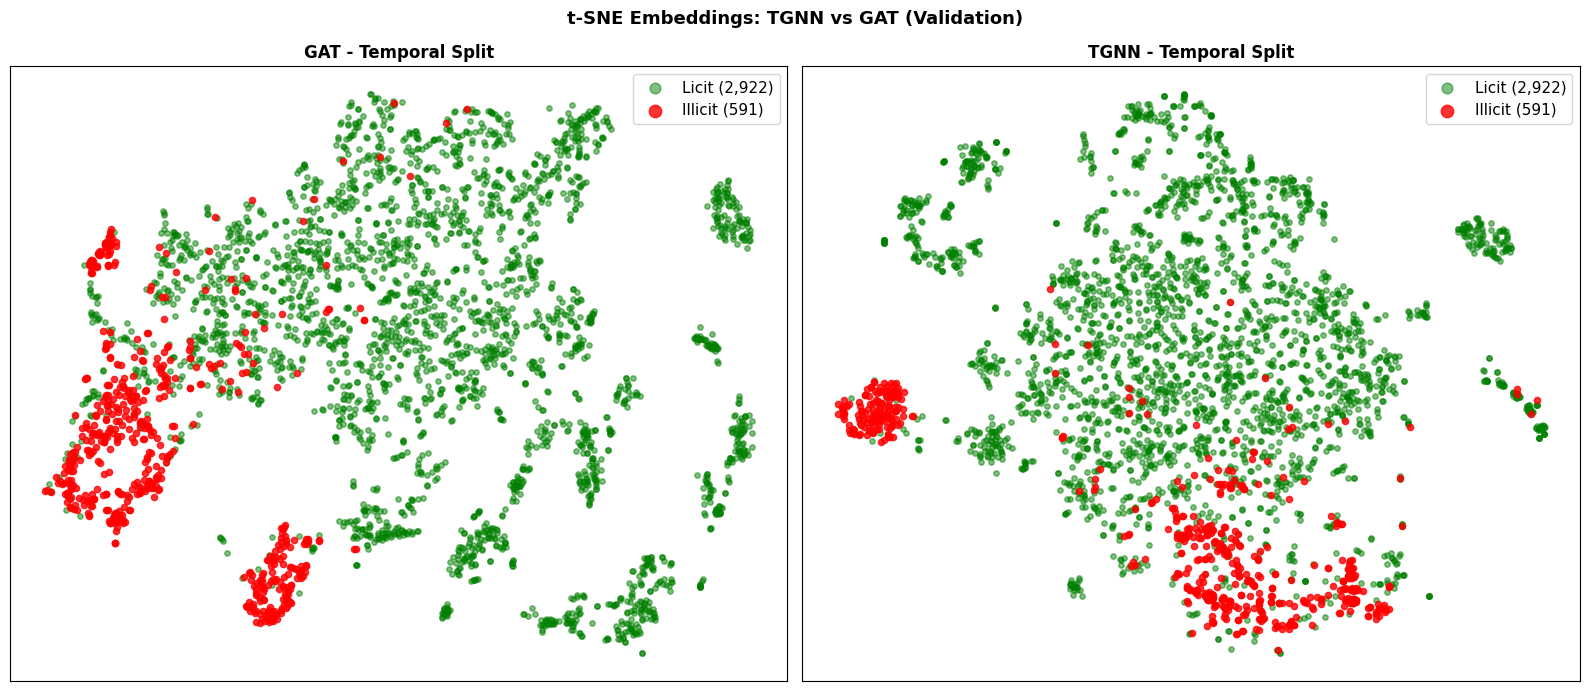

In [ ]:
# ============================================================================
# CELLULE: t-SNE GAT
# ============================================================================
print("="*60)
print("VISUALISATION t-SNE - GAT")
print("="*60)

gat_model.eval()
with torch.no_grad():
    emb_gat = gat_model.get_embeddings(data_gat.x, data_gat.edge_index)

emb_val_gat   = emb_gat[data_gat.val_idx].cpu().numpy()
labels_val_gat = data_gat.y[data_gat.val_idx].cpu().numpy()

print(f"🔧 Embeddings shape: {emb_val_gat.shape}")
print(f"🔧 Calcul t-SNE sur {len(val_idx_ts):,} points...")

z_gat = TSNE(
    n_components=2, perplexity=30, random_state=SEED
).fit_transform(emb_val_gat)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('t-SNE Embeddings: TGNN vs GAT (Validation)',
             fontsize=13, fontweight='bold')

for ax, (z, labels_v), title in zip(
    axes,
    [(z_gat, labels_val_gat)],   # GAT
    ['GAT - Temporal Split']
):
    licit_m   = labels_v == 0
    illicit_m = labels_v == 1

    ax.scatter(z[licit_m, 0],   z[licit_m, 1],
               s=15, c='green', alpha=0.5,
               label=f'Licit ({licit_m.sum():,})')
    ax.scatter(z[illicit_m, 0], z[illicit_m, 1],
               s=20, c='red',   alpha=0.8,
               label=f'Illicit ({illicit_m.sum():,})')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=11, markerscale=2)

# Ajouter aussi TGNN pour comparaison
model_ts.eval()
with torch.no_grad():
    emb_tgnn_val = model_ts.get_embeddings(
        data_train_ts.x, data_train_ts.edge_index
    )[data_train_ts.val_idx].cpu().numpy()

labels_val_tgnn = data_train_ts.y[data_train_ts.val_idx].cpu().numpy()

z_tgnn = TSNE(
    n_components=2, perplexity=30, random_state=SEED
).fit_transform(emb_tgnn_val)

ax2 = axes[1]
licit_m_t   = labels_val_tgnn == 0
illicit_m_t = labels_val_tgnn == 1

ax2.scatter(z_tgnn[licit_m_t, 0],   z_tgnn[licit_m_t, 1],
            s=15, c='green', alpha=0.5,
            label=f'Licit ({licit_m_t.sum():,})')
ax2.scatter(z_tgnn[illicit_m_t, 0], z_tgnn[illicit_m_t, 1],
            s=20, c='red',   alpha=0.8,
            label=f'Illicit ({illicit_m_t.sum():,})')
ax2.set_title('TGNN - Temporal Split', fontweight='bold')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.legend(fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('tsne_tgnn_vs_gat.png', dpi=300, bbox_inches='tight')
print("✓ Figure sauvegardée: tsne_tgnn_vs_gat.png")
plt.show()

# AJOUTER DES AMELIORATIONS AU GAT

# CELLULE: DÉFINITION DU MODÈLE GAT AMÉLIORÉ

In [ ]:
# ============================================================================
# CELLULE: GATImproved AVEC MLP HEAD (2 LAYERS)
# ============================================================================

class GATImproved(torch.nn.Module):
    """
    GAT amélioré v3 — leçons tirées des v1/v2 :
      - hidden=64, heads=8  (même capacité que GAT original)
      - Résiduelle sur couche 1 uniquement
      - PAS de feature dropout en entrée
      - DropEdge conservé
      - Initialisation résiduelle à zéro
      - MLP Head 2 layers (même que TGNN, GAT, TD-GNN)
    """
    def __init__(self, dim_in, dim_h=64, dim_out=1, heads=8):
        super(GATImproved, self).__init__()

        # ── Couche 1 avec résiduelle ──────────────────────────────────────
        self.norm1     = BatchNorm1d(dim_in)
        self.res_proj1 = nn.Linear(dim_in, dim_h * heads, bias=False)
        self.gat1      = GATv2Conv(dim_in, dim_h,
                                   heads=heads, dropout=0.3)

        # ── Couche 2 sans résiduelle ──────────────────────────────────────
        self.norm2 = BatchNorm1d(dim_h * heads)
        self.gat2  = GATv2Conv(dim_h * heads, dim_h,   # ← dim_h pas dim_out
                               heads=heads, concat=False, dropout=0.6)

        # ── MLP Head 2 layers ─────────────────────────────────────────────
        self.head = nn.Sequential(
            BatchNorm1d(dim_h),
            nn.Linear(dim_h, dim_h // 2),   # Layer 1: dim_h → dim_h//2
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dim_h // 2, dim_out)  # Layer 2: dim_h//2 → 1
        )

        # ── Init résiduelle à zéro ────────────────────────────────────────
        nn.init.zeros_(self.res_proj1.weight)

    def forward(self, x, edge_index, drop_edge_p=0.0):
        # DropEdge uniquement pendant l'entraînement
        if self.training and drop_edge_p > 0:
            edge_index, _ = dropout_edge(edge_index, p=drop_edge_p,
                                         training=self.training)

        # Couche 1 avec résiduelle
        h  = self.norm1(x)
        h1 = self.gat1(h, edge_index)
        h1 = h1 + self.res_proj1(x)

        # Couche 2
        h2  = self.norm2(h1)
        h2  = F.leaky_relu(h2)
        h2  = self.gat2(h2, edge_index)

        # MLP Head
        out = self.head(h2)
        return out

    def get_embeddings(self, x, edge_index):
        with torch.no_grad():
            h  = self.norm1(x)
            h1 = self.gat1(h, edge_index)
            h1 = h1 + self.res_proj1(x)
            h2 = self.norm2(h1)
            h2 = F.leaky_relu(h2)
            h2 = self.gat2(h2, edge_index)
        return h2


HIDDEN_SIZE_IMP = 64
HEADS_IMP       = 8

# Vérification
_tmp = GATImproved(INPUT_DIM, HIDDEN_SIZE_IMP, OUTPUT_DIM, HEADS_IMP)
p_imp = sum(p.numel() for p in _tmp.parameters())

print("✓ GATImproved v3 défini avec MLP head (2 layers)")
print(f"  GNN:  GATv2Conv({INPUT_DIM}→{HIDDEN_SIZE_IMP}×{HEADS_IMP}) + GATv2Conv→{HIDDEN_SIZE_IMP}")
print(f"  MLP:  {HIDDEN_SIZE_IMP} → {HIDDEN_SIZE_IMP//2} → {OUTPUT_DIM}")
print(f"  Résiduelle:   couche 1, initialisée à zéro")
print(f"  DropEdge:     0.15")
print(f"  Total params: {p_imp:,}")
del _tmp

✓ GATImproved v3 défini avec MLP head (2 layers)
  GNN:  GATv2Conv(182→64×8) + GATv2Conv→64
  MLP:  64 → 32 → 1
  Résiduelle:   couche 1, initialisée à zéro
  DropEdge:     0.15
  Total params: 811,117


# CELLULE: ENTRAÎNEMENT GAT AMÉLIORÉ AVEC TEMPORAL SPLIT

In [ ]:
# ============================================================================
# CELLULE: ENTRAÎNEMENT GAT AMÉLIORÉ v3 (avec LR warmup)
# ============================================================================

from torch_geometric.utils import dropout_edge  # ← fix NameError

DROP_EDGE_P   = 0.15
WARMUP_EPOCHS = 10

def train_evaluate_gat_improved(model, data, criterion, optimizer,
                                num_epochs, checkpoints_dir, model_filename,
                                patience=PATIENCE, drop_edge_p=0.15,
                                warmup_epochs=10):
    best_model_wts  = copy.deepcopy(model.state_dict())
    best_val_score  = 0.0   # score combiné F1×0.4 + Recall×0.6
    best_val_auprc  = 0.0   # sauvegardé pour référence
    best_epoch      = 0
    patience_ctr    = 0
    base_lr         = optimizer.param_groups[0]['lr']

    os.makedirs(checkpoints_dir, exist_ok=True)

    history_imp = {
        'train_loss': [], 'val_loss':      [],
        'train_acc':  [], 'val_acc':       [],
        'val_auprc':  [], 'val_auroc':     [],
        'val_f1':     [], 'val_precision': [], 'val_recall': []
    }

    print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
          f"{'Val Loss':>10} {'Val Acc':>9} "
          f"{'Val F1':>8} {'Val AUPRC':>10} {'Val Recall':>11}")
    print("-" * 85)

    for epoch in range(num_epochs + 1):

        # ── LR Warmup ─────────────────────────────────────────────────────
        if epoch < warmup_epochs:
            warmup_lr = base_lr * (epoch + 1) / warmup_epochs
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr
        elif epoch == warmup_epochs:
            for pg in optimizer.param_groups:
                pg['lr'] = base_lr

        # ── TRAIN ─────────────────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        out  = model(data.x, data.edge_index, drop_edge_p=drop_edge_p)
        loss = criterion(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )
        acc = accuracy_binary(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )
        loss.backward()
        optimizer.step()

        # ── VALIDATION (pas de DropEdge) ──────────────────────────────────
        model.eval()
        with torch.no_grad():
            out_val = model(data.x, data.edge_index, drop_edge_p=0.0)

            val_loss = criterion(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            ).item()
            val_acc = accuracy_binary(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            )
            y_true_v   = data.y[data.val_idx].cpu().numpy()
            y_logits_v = out_val[data.val_idx].squeeze(1).cpu().numpy()
            val_m      = compute_all_metrics(y_true_v, y_logits_v,threshold=0.913 )

        # ── Historique ────────────────────────────────────────────────────
        history_imp['train_loss'].append(loss.item())
        history_imp['val_loss'].append(val_loss)
        history_imp['train_acc'].append(acc)
        history_imp['val_acc'].append(val_acc)
        history_imp['val_auprc'].append(val_m['auprc'])
        history_imp['val_auroc'].append(val_m['auroc'])
        history_imp['val_f1'].append(val_m['f1'])
        history_imp['val_precision'].append(val_m['precision'])
        history_imp['val_recall'].append(val_m['recall'])

        # ── Score combiné F1×0.4 + Recall×0.4 + Precision×0.2 ───────────
        val_score = (0.4 * val_m['f1'] +
                     0.4 * val_m['recall'] +
                     0.2 * val_m['precision'])

        # ── Early stopping sur le score combiné ───────────────────────────
        if val_score > best_val_score:
            best_val_score  = val_score
            best_val_auprc  = val_m['auprc']
            best_epoch      = epoch
            patience_ctr    = 0
            best_model_wts  = copy.deepcopy(model.state_dict())
            torch.save(
                {'state_dict': best_model_wts},
                os.path.join(checkpoints_dir, model_filename)
            )
        else:
            patience_ctr += 1

        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"{epoch:>6} {loss.item():>11.4f} {acc*100:>9.2f}% "
                  f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
                  f"{val_m['f1']:>8.4f} {val_m['auprc']:>10.4f} "
                  f"{val_m['recall']:>10.4f}  lr={current_lr:.5f}")

        if patience_ctr >= patience:
            print(f"\n⚠ Early stopping à l'epoch {epoch} "
                  f"(patience={patience})")
            break

    model.load_state_dict(best_model_wts)
    print(f"\n✓ Entraînement terminé!")
    print(f"  Meilleure epoch:                       {best_epoch}")
    print(f"  Meilleur score (F1×0.4 + Recall×0.6): {best_val_score:.4f}")
    print(f"  AUPRC à cette epoch:                   {best_val_auprc:.4f}")
    return model, history_imp, best_val_auprc, best_epoch


# ── Libérer VRAM avant initialisation ─────────────────────────────────────────
import gc
gc.collect()
torch.cuda.empty_cache()

# ── Initialisation ────────────────────────────────────────────────────────────
torch.manual_seed(SEED)

gat_imp_model = GATImproved(
    dim_in  = INPUT_DIM,
    dim_h   = HIDDEN_SIZE_IMP,
    dim_out = OUTPUT_DIM,
    heads   = HEADS_IMP
).to(device)

optimizer_gat_imp = torch.optim.Adam(
    gat_imp_model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)
criterion_gat_imp = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_ts)

CHECKPOINTS_DIR_GAT_IMP = './models/elliptic_gat_improved'

total_params_gat_imp = sum(p.numel() for p in gat_imp_model.parameters())
print(f"\n✓ Modèle GATImproved v3 initialisé:")
print(f"  Hidden:       {HIDDEN_SIZE_IMP} × {HEADS_IMP} heads = {HIDDEN_SIZE_IMP * HEADS_IMP}")
print(f"  Total params: {total_params_gat_imp:,}")
print(f"  Warmup:       {WARMUP_EPOCHS} epochs")
print(f"  Early stop:   F1×0.4 + Recall×0.6")

gat_imp_model, history_gat_imp, best_auprc_gat_imp, best_epoch_gat_imp = \
    train_evaluate_gat_improved(
        model           = gat_imp_model,
        data            = data_gat,
        criterion       = criterion_gat_imp,
        optimizer       = optimizer_gat_imp,
        num_epochs      = NUM_EPOCHS,
        checkpoints_dir = CHECKPOINTS_DIR_GAT_IMP,
        model_filename  = 'gat_improved_best.pth.tar',
        patience        = PATIENCE,
        drop_edge_p     = DROP_EDGE_P,
        warmup_epochs   = WARMUP_EPOCHS
    )


✓ Modèle GATImproved v3 initialisé:
  Hidden:       64 × 8 heads = 512
  Total params: 811,117
  Warmup:       10 epochs
  Early stop:   F1×0.4 + Recall×0.6

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
-------------------------------------------------------------------------------------
     0      1.2631     42.99%     1.4265    87.05%   0.0000     0.5762     0.0000  lr=0.00050
    10      1.1048     53.19%     1.3849    70.20%   0.0000     0.6020     0.0000  lr=0.00500
    20      0.6914     82.26%     0.9396    66.64%   0.0000     0.6400     0.0000  lr=0.00500
    30      0.5055     87.04%     0.8377    69.94%   0.6010     0.6877     0.6971  lr=0.00500
    40      0.4229     88.73%     0.8085    75.18%   0.6219     0.6932     0.7056  lr=0.00500
    50      0.3645     91.36%     0.9083    76.86%   0.6459     0.6723     0.6836  lr=0.00500
    60      0.3123     92.13%     0.7850    78.45%   0.6561     0.6605     0.7022  lr=0.00500
    70      0.

In [ ]:
# ============================================================================
# CELLULE: COMPARAISON TGNN vs GAT vs GAT AMÉLIORÉ
# ============================================================================
print("="*60)
print("COMPARAISON TGNN vs GAT vs GAT AMÉLIORÉ")
print("="*60)

# Évaluation GAT amélioré (même logique que GAT)
gat_imp_model.load_state_dict(
    torch.load(os.path.join(CHECKPOINTS_DIR_GAT_IMP,
                            'gat_improved_best.pth.tar'))['state_dict']
)
gat_imp_model.eval()

with torch.no_grad():
    out_imp = gat_imp_model(data_gat.x, data_gat.edge_index, drop_edge_p=0.0)

# Val
y_true_val_imp   = data_gat.y[data_gat.val_idx].cpu().numpy()
y_logits_val_imp = out_imp[data_gat.val_idx].squeeze(1).cpu().numpy()
val_metrics_imp  = compute_all_metrics(y_true_val_imp, y_logits_val_imp)

# Test
test_labeled_idx_imp = df.index[
    df['time_step'].isin(TEST_TS) & (df['is_labeled'] == 1)
].values
y_true_test_imp   = data_gat.y[test_labeled_idx_imp].cpu().numpy()
y_logits_test_imp = out_imp[test_labeled_idx_imp].squeeze(1).cpu().numpy()
test_metrics_imp  = compute_all_metrics(y_true_test_imp, y_logits_test_imp)

metriques_list = [
    ('AUPRC ⭐',  'auprc'),
    ('AUROC',     'auroc'),
    ('F1-Score',  'f1'),
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('Accuracy',  'accuracy'),
]

for split_name, m_tgnn, m_gat, m_imp in [
    ('VALIDATION (ts 35-39)', val_metrics_ts,  val_metrics_gat,  val_metrics_imp),
    ('TEST (ts 40-49)',       test_metrics_ts, test_metrics_gat, test_metrics_imp),
]:
    print(f"\n📊 {split_name}:")
    print(f"  {'Métrique':<22} {'TGNN':>8} {'GAT':>8} {'GAT+':>8} "
          f"{'Δ(GAT+-GAT)':>13}")
    print(f"  {'-'*65}")
    for label, key in metriques_list:
        v_t = m_tgnn[key]; v_g = m_gat[key]; v_i = m_imp[key]
        d   = v_i - v_g
        arr = "↑" if d > 0 else ("↓" if d < 0 else "=")
        print(f"  {label:<22} {v_t:>8.4f} {v_g:>8.4f} {v_i:>8.4f} "
              f"   {arr}{abs(d):>8.4f}")

# Infos modèles
print(f"\n📊 INFOS MODÈLES:")
print(f"  {'':22} {'TGNN':>10} {'GAT':>10} {'GAT+':>10}")
print(f"  {'-'*55}")
print(f"  {'Params':22} "
      f"{sum(p.numel() for p in model_ts.parameters()):>10,} "
      f"{total_params_gat:>10,} "
      f"{total_params_gat_imp:>10,}")
print(f"  {'Best epoch':22} {best_epoch_ts:>10} "
      f"{best_epoch_gat:>10} {best_epoch_gat_imp:>10}")
print(f"  {'Best Val AUPRC':22} {best_val_auprc_ts:>10.4f} "
      f"{best_auprc_gat:>10.4f} {best_auprc_gat_imp:>10.4f}")

COMPARAISON TGNN vs GAT vs GAT AMÉLIORÉ

📊 VALIDATION (ts 35-39):
  Métrique                   TGNN      GAT     GAT+   Δ(GAT+-GAT)
  -----------------------------------------------------------------
  AUPRC ⭐                  0.8006   0.8409   0.8630    ↑  0.0222
  AUROC                    0.9560   0.9716   0.9764    ↑  0.0048
  F1-Score                 0.7152   0.7321   0.7298    ↓  0.0022
  Recall                   0.9391   0.9662   0.9712    ↑  0.0051
  Precision                0.5775   0.5893   0.5845    ↓  0.0047
  Accuracy                 0.8742   0.8810   0.8790    ↓  0.0020

📊 TEST (ts 40-49):
  Métrique                   TGNN      GAT     GAT+   Δ(GAT+-GAT)
  -----------------------------------------------------------------
  AUPRC ⭐                  0.4038   0.1464   0.3129    ↑  0.1665
  AUROC                    0.8857   0.7748   0.8778    ↑  0.1030
  F1-Score                 0.3308   0.1885   0.2718    ↑  0.0832
  Recall                   0.7932   0.8532   0.8717    ↑  0.0

In [ ]:
# Après le calcul de val_metrics_imp et test_metrics_imp
# (juste avant ou après le tableau de comparaison)

print(f"\n📊 CLASSIFICATION REPORT - GAT Amélioré Validation:")
print(classification_report(
    y_true_val_imp,
    val_metrics_imp['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))

print(f"\n📊 CLASSIFICATION REPORT - GAT Amélioré Test:")
print(classification_report(
    y_true_test_imp,
    test_metrics_imp['y_pred'],
    target_names=['licit', 'illicit'],
    digits=2
))


📊 CLASSIFICATION REPORT - GAT Amélioré Validation:
              precision    recall  f1-score   support

       licit       0.99      0.86      0.92      2922
     illicit       0.58      0.97      0.73       591

    accuracy                           0.88      3513
   macro avg       0.79      0.92      0.83      3513
weighted avg       0.92      0.88      0.89      3513


📊 CLASSIFICATION REPORT - GAT Amélioré Test:
              precision    recall  f1-score   support

       licit       0.99      0.68      0.81     15587
     illicit       0.16      0.87      0.27      1083

    accuracy                           0.70     16670
   macro avg       0.57      0.78      0.54     16670
weighted avg       0.93      0.70      0.77     16670



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TD-GNN DATASET OBJECT — run this cell directly before TD-GNN training
# ══════════════════════════════════════════════════════════════════════════════

from torch_geometric.data import Data

# ── 1. Node features ──────────────────────────────────────────────────────────
numeric_features_tdgnn = [
    col for col in df.columns
    if col not in ['txId', 'time_step', 'class_encoded', 'is_labeled', 'split']
]

X_tdgnn = df[numeric_features_tdgnn].copy()
for col in numeric_features_tdgnn:
    X_tdgnn[col] = pd.to_numeric(X_tdgnn[col], errors='coerce')
X_tdgnn = X_tdgnn.fillna(0)

node_features_tdgnn = torch.tensor(X_tdgnn.values, dtype=torch.float32)

if torch.isnan(node_features_tdgnn).any():
    node_features_tdgnn = torch.nan_to_num(node_features_tdgnn, nan=0.0)
if torch.isinf(node_features_tdgnn).any():
    node_features_tdgnn = torch.nan_to_num(node_features_tdgnn, posinf=0.0, neginf=0.0)

# ── 2. Labels ─────────────────────────────────────────────────────────────────
labels_tdgnn = df['class_encoded'].copy().replace(2, 0)
labels_tdgnn = torch.tensor(labels_tdgnn.values, dtype=torch.float32)

# ── 3. time_step per node ─────────────────────────────────────────────────────
time_step_tdgnn = torch.tensor(df['time_step'].values, dtype=torch.long)

# ── 4. is_labeled mask ────────────────────────────────────────────────────────
is_labeled_tdgnn = torch.tensor(df['is_labeled'].values, dtype=torch.bool)

# ── 5. Edge index ─────────────────────────────────────────────────────────────
txId_to_idx = {str(tx): idx for idx, tx in enumerate(df['txId'].astype(str))}

edges_tdgnn = edges.copy()
if 'source' not in edges_tdgnn.columns:
    edges_tdgnn.columns = ['source', 'target'] + list(edges_tdgnn.columns[2:])

edges_tdgnn['source'] = edges_tdgnn['source'].astype(str)
edges_tdgnn['target'] = edges_tdgnn['target'].astype(str)
edges_tdgnn['src_idx'] = edges_tdgnn['source'].map(txId_to_idx)
edges_tdgnn['tgt_idx'] = edges_tdgnn['target'].map(txId_to_idx)

n_before = len(edges_tdgnn)
edges_tdgnn = edges_tdgnn.dropna(subset=['src_idx', 'tgt_idx'])
edges_tdgnn = edges_tdgnn.astype({'src_idx': int, 'tgt_idx': int})
n_dropped   = n_before - len(edges_tdgnn)

edge_index_tdgnn = torch.tensor(
    edges_tdgnn[['src_idx', 'tgt_idx']].values.T,
    dtype=torch.long
).contiguous()

edge_weights_tdgnn = torch.ones(edge_index_tdgnn.shape[1], dtype=torch.float32)

# ── 6. Temporal train / val / test masks ──────────────────────────────────────
TRAIN_TS_TDGNN = list(range(1,  35))   # timesteps 1–34
VAL_TS_TDGNN   = list(range(35, 50))   # timesteps 35–49
TEST_TS_TDGNN  = list(range(35, 50))   # timesteps 35–49

train_mask_tdgnn = (
    torch.tensor(df['time_step'].isin(TRAIN_TS_TDGNN).values) & is_labeled_tdgnn
)
val_mask_tdgnn = (
    torch.tensor(df['time_step'].isin(VAL_TS_TDGNN).values)   & is_labeled_tdgnn
)
test_mask_tdgnn = (
    torch.tensor(df['time_step'].isin(TEST_TS_TDGNN).values)   & is_labeled_tdgnn
)

# ── 7. Build PyG Data object ──────────────────────────────────────────────────
data_tdgnn = Data(
    x            = node_features_tdgnn,       # (N, F)
    edge_index   = edge_index_tdgnn,          # (2, E)
    edge_weights = edge_weights_tdgnn,        # (E,)
    y            = labels_tdgnn,              # (N,)
    time_step    = time_step_tdgnn,           # (N,)  ← what TD-GNN needs
    is_labeled   = is_labeled_tdgnn,          # (N,)
    train_mask   = train_mask_tdgnn,          # (N,)
    val_mask     = val_mask_tdgnn,            # (N,)
    test_mask    = test_mask_tdgnn,           # (N,)
)

# ── 8. Verification ───────────────────────────────────────────────────────────
print("TD-GNN Data object")
print("=" * 50)
print(f"  Nodes          : {data_tdgnn.num_nodes:,}")
print(f"  Features       : {data_tdgnn.num_features}")
print(f"  Edges          : {data_tdgnn.num_edges:,}")
print(f"  Edges dropped  : {n_dropped:,}")
print()
print(f"  time_step      : {data_tdgnn.time_step.shape} "
      f"| range [{data_tdgnn.time_step.min()}, {data_tdgnn.time_step.max()}]")
print()
print(f"  train_mask     : {data_tdgnn.train_mask.sum():,} labeled nodes "
      f"(ts 1–34)")
print(f"  val_mask       : {data_tdgnn.val_mask.sum():,} labeled nodes "
      f"(ts 35–49)")
print(f"  test_mask      : {data_tdgnn.test_mask.sum():,} labeled nodes "
      f"(ts 35–49)")
print()

y_train = data_tdgnn.y[data_tdgnn.train_mask]
y_val   = data_tdgnn.y[data_tdgnn.val_mask]
print(f"  Train illicit  : {(y_train == 1).sum():,} / {len(y_train):,} "
      f"({(y_train == 1).float().mean()*100:.1f}%)")
print(f"  Val   illicit  : {(y_val   == 1).sum():,} / {len(y_val):,} "
      f"({(y_val   == 1).float().mean()*100:.1f}%)")
print()
print(f"  INPUT_DIM_TDGNN = {data_tdgnn.num_features}")
print("=" * 50)
print("✅ data_tdgnn ready — run TD-GNN training cell now")

INPUT_DIM_TDGNN = data_tdgnn.num_features

TD-GNN Data object
  Nodes          : 203,769
  Features       : 183
  Edges          : 234,355
  Edges dropped  : 0

  time_step      : torch.Size([203769]) | range [1, 49]

  train_mask     : 29,894 labeled nodes (ts 1–34)
  val_mask       : 16,670 labeled nodes (ts 35–49)
  test_mask      : 16,670 labeled nodes (ts 35–49)

  Train illicit  : 3,462 / 29,894 (11.6%)
  Val   illicit  : 1,083 / 16,670 (6.5%)

  INPUT_DIM_TDGNN = 183
✅ data_tdgnn ready — run TD-GNN training cell now


# ATGAT Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
import math

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODULE 1: Advanced Temporal Embedding
# ══════════════════════════════════════════════════════════════════════════════

class AdvancedTemporalEmbedding(nn.Module):
    def __init__(self, dt: int, dropout: float = 0.1):
        super().__init__()
        self.dt   = dt
        self.d1   = dt // 4
        self.d2   = dt // 2
        self.d3   = dt // 4
        # dpos must be even for sin/cos pairing
        self.dpos = self.d2 if self.d2 % 2 == 0 else self.d2 + 1

        self.proj_delta = nn.Linear(1, self.d1)
        self.proj_ms    = nn.Linear(3, self.d3)
        self.proj_pe    = nn.Linear(2 * self.dpos, self.d2)

        total = self.d1 + self.d3 + self.d2
        self.fusion = nn.Sequential(
            nn.Linear(total, dt),
            nn.LayerNorm(dt),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def _positional_encoding(self, t: torch.Tensor) -> torch.Tensor:
        """t: (N,) → (N, dpos)"""
        t = t.float().unsqueeze(1)                              # (N, 1)
        # FIX 1: pass device=t.device so div is always on the right device
        div = torch.exp(
            torch.arange(0, self.dpos, 2, dtype=torch.float32, device=t.device)
            * -(math.log(10000.0) / self.dpos)
        )                                                       # (dpos/2,)
        pe = torch.zeros(t.shape[0], self.dpos, device=t.device)
        pe[:, 0::2] = torch.sin(t * div)
        # FIX 2: div already has dpos//2 elements — no extra slice needed
        pe[:, 1::2] = torch.cos(t * div)
        return pe                                               # (N, dpos)

    def forward(self, t_i: torch.Tensor, t_j: torch.Tensor) -> torch.Tensor:
        """t_i, t_j: (E,) → (E, dt)"""
        delta = (t_i - t_j).abs().float()                      # (E,)

        # a) basic projection
        f_delta = self.proj_delta(delta.unsqueeze(1))           # (E, d1)

        # b) multi-scale
        f_ms_cat = torch.stack(
            [delta, torch.log(delta + 1.0), torch.sqrt(delta + 1.0)], dim=1
        )                                                       # (E, 3)
        f_ms = self.proj_ms(f_ms_cat)                          # (E, d3)

        # c) periodic position encoding
        pe_i   = self._positional_encoding(t_i)                # (E, dpos)
        pe_j   = self._positional_encoding(t_j)                # (E, dpos)
        f_pe   = self.proj_pe(torch.cat([pe_i, pe_j], dim=1)) # (E, d2)

        cat = torch.cat([f_delta, f_ms, f_pe], dim=1)          # (E, dt)
        return self.fusion(cat)                                 # (E, dt)


# ══════════════════════════════════════════════════════════════════════════════
# MODULE 2: Temporal-Aware Triple Attention GAT Layer
# ══════════════════════════════════════════════════════════════════════════════

class TripleAttentionGATLayer(MessagePassing):
    def __init__(self, in_dim: int, out_dim: int, dt: int,
                 heads: int = 4, dropout: float = 0.1):
        super().__init__(aggr='add')
        assert out_dim % heads == 0
        self.heads    = heads
        self.head_dim = out_dim // heads
        self.out_dim  = out_dim
        self.scale    = self.head_dim ** -0.5

        # structural attention
        self.W_q_s = nn.Linear(in_dim, out_dim, bias=False)
        self.W_k_s = nn.Linear(in_dim, out_dim, bias=False)
        self.W_v_s = nn.Linear(in_dim, out_dim, bias=False)

        # temporal attention
        self.W_q_t = nn.Linear(in_dim, out_dim, bias=False)
        self.W_k_t = nn.Linear(dt,     out_dim, bias=False)
        self.W_v_t = nn.Linear(dt,     out_dim, bias=False)

        # global context (edge-level score)
        self.W_global = nn.Linear(in_dim + dt, heads, bias=False)

        # FIX 3: fusion network takes node features (in_dim) as input,
        # not aggregated value vectors — gives proper per-node weights
        self.fusion_net = nn.Sequential(
            nn.Linear(in_dim, 3),
            nn.Softmax(dim=-1),
        )

        self.W_out   = nn.Linear(out_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        # norm lives in ATGAT.forward (residual wrapper), not here

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                e_time: torch.Tensor) -> torch.Tensor:
        """
        x:          (N, in_dim)
        edge_index: (2, E)
        e_time:     (E, dt)
        returns:    (N, out_dim)
        """
        row, col = edge_index

        # ── structural attention ─────────────────────────────────────────
        q_s = self.W_q_s(x)[row].view(-1, self.heads, self.head_dim)
        k_s = self.W_k_s(x)[col].view(-1, self.heads, self.head_dim)
        v_s = self.W_v_s(x)[col].view(-1, self.heads, self.head_dim)
        alpha_struct = (q_s * k_s).sum(-1) * self.scale        # (E, heads)

        # ── temporal attention ───────────────────────────────────────────
        q_t = self.W_q_t(x)[row].view(-1, self.heads, self.head_dim)
        k_t = self.W_k_t(e_time).view(-1, self.heads, self.head_dim)
        v_t = self.W_v_t(e_time).view(-1, self.heads, self.head_dim)
        alpha_temp = (q_t * k_t).sum(-1) * self.scale          # (E, heads)

        # ── global context attention ─────────────────────────────────────
        global_feat  = torch.cat([x[row], e_time], dim=1)      # (E, in_dim+dt)
        alpha_global = self.W_global(global_feat)               # (E, heads)

        # ── softmax normalise per target node ────────────────────────────
        N   = x.size(0)
        a_s = softmax(alpha_struct, col, num_nodes=N)           # (E, heads)
        a_t = softmax(alpha_temp,   col, num_nodes=N)
        a_g = softmax(alpha_global, col, num_nodes=N)

        # FIX 4: adaptive fusion weights derived from source-node features
        # → (E, 3), one weight triplet per edge
        weights = self.fusion_net(x[row])                       # (E, 3)
        ws = weights[:, 0:1]                                    # (E, 1)
        wt = weights[:, 1:2]
        wg = weights[:, 2:3]

        # ── combined attention ───────────────────────────────────────────
        alpha = ws * a_s + wt * a_t + wg * a_g                 # (E, heads)
        alpha = self.dropout(alpha)

        # FIX 5: values come from structural stream only (paper eq. 5
        # fuses attention coefficients, not values from three streams).
        # Temporal values v_t are already captured via alpha_temp.
        # If you want to blend value streams too, use ws*v_s + wt*v_t.
        V_combined = ws.unsqueeze(-1) * v_s + wt.unsqueeze(-1) * v_t  # (E,H,hd)

        out = self.propagate(
            edge_index,
            alpha=alpha,
            V=V_combined,
            size=(N, N),
        )                                                       # (N, out_dim)

        return self.W_out(out)                                  # (N, out_dim)

    def message(self, alpha: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
        # alpha: (E, heads), V: (E, heads, head_dim)
        return (alpha.unsqueeze(-1) * V).view(-1, self.out_dim)

    def update(self, aggr_out: torch.Tensor) -> torch.Tensor:
        return aggr_out


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL ATGAT MODEL
# ══════════════════════════════════════════════════════════════════════════════

class ATGAT(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, dt: int = 32,
                 heads: int = 4, n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        assert dt % 4 == 0, "dt must be divisible by 4"
        self.dropout = dropout

        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.temporal_emb = AdvancedTemporalEmbedding(dt=dt, dropout=dropout)

        self.layers = nn.ModuleList([
            TripleAttentionGATLayer(
                in_dim=hidden, out_dim=hidden, dt=dt,
                heads=heads, dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden) for _ in range(n_layers)
        ])

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                t: torch.Tensor) -> torch.Tensor:
        row, col = edge_index
        # FIX 1 (root cause of RuntimeError): t is an integer tensor —
        # cast to float BEFORE passing to temporal embedding so that
        # all arithmetic happens on the same device/dtype as x
        e_time = self.temporal_emb(t[row].float(), t[col].float())  # (E, dt)

        h = self.input_proj(x)

        for layer, norm in zip(self.layers, self.layer_norms):
            h_new = layer(h, edge_index, e_time)
            h     = norm(h + h_new)                            # residual ✓
            h     = F.dropout(h, p=self.dropout, training=self.training)

        return self.head(h)                                    # (N, 1)


print("✅ ATGAT architecture defined")
print("   Modules: AdvancedTemporalEmbedding | TripleAttentionGATLayer | ATGAT")

✅ ATGAT architecture defined
   Modules: AdvancedTemporalEmbedding | TripleAttentionGATLayer | ATGAT


#Cell 2 — Instantiate with cost-sensitive loss

In [ ]:
# ── Convert boolean masks → integer index tensors ─────────────────────────
data_tdgnn.train_idx = data_tdgnn.train_mask.nonzero(as_tuple=False).squeeze(1)
data_tdgnn.val_idx   = data_tdgnn.val_mask.nonzero(as_tuple=False).squeeze(1)
data_tdgnn.test_idx  = data_tdgnn.test_mask.nonzero(as_tuple=False).squeeze(1)

print(f"train_idx : {data_tdgnn.train_idx.shape[0]:,} nodes")
print(f"val_idx   : {data_tdgnn.val_idx.shape[0]:,} nodes")
print(f"test_idx  : {data_tdgnn.test_idx.shape[0]:,} nodes")

train_idx : 29,894 nodes
val_idx   : 16,670 nodes
test_idx  : 16,670 nodes


In [ ]:
# ── hyperparameters ───────────────────────────────────────────────────────
IN_DIM   = data_tdgnn.x.shape[1]
HIDDEN   = 64
DT       = 32        # temporal embedding dim — must be divisible by 4
HEADS    = 4
N_LAYERS = 2
DROPOUT  = 0.3
LR       = 1e-3
WD       = 1e-5

# ── model ─────────────────────────────────────────────────────────────────
atgat_model = ATGAT(
    in_dim   = IN_DIM,
    hidden   = HIDDEN,
    dt       = DT,
    heads    = HEADS,
    n_layers = N_LAYERS,
    dropout  = DROPOUT,
).to(device)

print(f"ATGAT initialised:")
print(f"  in_dim   : {IN_DIM}")
print(f"  hidden   : {HIDDEN}")
print(f"  dt       : {DT}  (d1={DT//4}, d2={DT//2}, d3={DT//4})")
print(f"  heads    : {HEADS}")
print(f"  layers   : {N_LAYERS}")
print(f"  params   : {sum(p.numel() for p in atgat_model.parameters()):,}")

# ── cost-sensitive loss  eq.(6): wpos = Nneg/Npos, wneg = 1 ─────────────
n_neg = (data_tdgnn.y[data_tdgnn.train_idx] == 0).sum().item()  # licit
n_pos = (data_tdgnn.y[data_tdgnn.train_idx] == 1).sum().item()  # illicit
w_pos = n_neg / n_pos

print(f"\nCost-sensitive loss:")
print(f"  Nneg (licit)   : {n_neg:,}")
print(f"  Npos (illicit) : {n_pos:,}")
print(f"  wpos = Nneg/Npos: {w_pos:.2f}")

pos_weight_atgat = torch.tensor([w_pos], dtype=torch.float32).to(device)
criterion_atgat  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_atgat)

optimizer_atgat = torch.optim.Adam(
    atgat_model.parameters(), lr=LR, weight_decay=WD
)

print(f"\n✅ criterion: BCEWithLogitsLoss(pos_weight={w_pos:.2f})")
print(f"✅ optimizer: Adam(lr={LR}, wd={WD})")

ATGAT initialised:
  in_dim   : 183
  hidden   : 64
  dt       : 32  (d1=8, d2=16, d3=8)
  heads    : 4
  layers   : 2
  params   : 66,407

Cost-sensitive loss:
  Nneg (licit)   : 26,432
  Npos (illicit) : 3,462
  wpos = Nneg/Npos: 7.63

✅ criterion: BCEWithLogitsLoss(pos_weight=7.63)
✅ optimizer: Adam(lr=0.001, wd=1e-05)


# Cell 3 — Training function

In [ ]:
import copy, os

def train_evaluate_atgat(model, data, criterion, optimizer,
                          num_epochs, checkpoints_dir, model_filename,
                          patience=20):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_score = 0.0
    best_val_auprc = 0.0
    best_epoch     = 0
    patience_ctr   = 0

    os.makedirs(checkpoints_dir, exist_ok=True)

    history = {
        'train_loss': [], 'val_loss':      [],
        'train_acc':  [], 'val_acc':       [],
        'val_f1':     [], 'val_auprc':     [],
        'val_auroc':  [], 'val_precision': [],
        'val_recall': [],
    }

    print(f"\n{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
          f"{'Val Loss':>10} {'Val Acc':>9} "
          f"{'Val F1':>8} {'Val AUPRC':>10} {'Val Recall':>11}")
    print("-" * 88)

    for epoch in range(num_epochs + 1):

        # ── TRAIN ─────────────────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        out  = model(data.x, data.edge_index, data.time_step)
        loss = criterion(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )
        acc  = accuracy_binary(
            out[data.train_idx],
            data.y[data.train_idx].unsqueeze(1)
        )
        loss.backward()
        optimizer.step()

        # ── VALIDATION ────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            out_val  = model(data.x, data.edge_index, data.time_step)
            val_loss = criterion(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            ).item()
            val_acc  = accuracy_binary(
                out_val[data.val_idx],
                data.y[data.val_idx].unsqueeze(1)
            )
            y_true_v   = data.y[data.val_idx].cpu().numpy()
            y_logits_v = out_val[data.val_idx].squeeze(1).cpu().numpy()
            val_m      = compute_all_metrics(y_true_v, y_logits_v)

        # ── history ───────────────────────────────────────────────────────
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['train_acc'].append(acc)
        history['val_acc'].append(val_acc)
        history['val_auprc'].append(val_m['auprc'])
        history['val_auroc'].append(val_m['auroc'])
        history['val_f1'].append(val_m['f1'])
        history['val_precision'].append(val_m['precision'])
        history['val_recall'].append(val_m['recall'])

        # ── score: AUPRC (threshold-independent, best for imbalance) ──────
        val_score = (0.4 * val_m['f1'] +
                     0.4 * val_m['recall'] +
                     0.2 * val_m['precision'])

        if val_score > best_val_score:
            best_val_score = val_score
            best_val_auprc = val_m['auprc']
            best_epoch     = epoch
            patience_ctr   = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(
                {'state_dict': best_model_wts, 'epoch': epoch,
                 'auprc': best_val_auprc},
                os.path.join(checkpoints_dir, model_filename)
            )
        else:
            patience_ctr += 1

        if epoch % 10 == 0:
            print(f"{epoch:>6} {loss.item():>11.4f} {acc*100:>9.2f}% "
                  f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
                  f"{val_m['f1']:>8.4f} {val_m['auprc']:>10.4f} "
                  f"{val_m['recall']:>10.4f}")

        if patience_ctr >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch} (patience={patience})")
            break

    model.load_state_dict(best_model_wts)
    print(f"\n✓ Training complete")
    print(f"  Best epoch : {best_epoch}")
    print(f"  Best AUPRC : {best_val_auprc:.4f}")

    return model, history, best_val_auprc, best_epoch


print("✅ train_evaluate_atgat defined")

✅ train_evaluate_atgat defined


In [ ]:
data_tdgnn = data_tdgnn.to(device)

In [ ]:
atgat_model, history_atgat, best_auprc_atgat, best_epoch_atgat = \
    train_evaluate_atgat(
        model           = atgat_model,
        data            = data_tdgnn,        # same data object — has time_step
        criterion       = criterion_atgat,
        optimizer       = optimizer_atgat,
        num_epochs      = 200,
        checkpoints_dir = CHECKPOINTS_DIR,
        model_filename  = "best_atgat.pth",
        patience        = 50,
    )


 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
----------------------------------------------------------------------------------------
     0      0.0685     99.28%     0.3007    97.82%   0.8302     0.9127     0.8218
    10      0.0566     99.40%     0.4664    97.94%   0.8277     0.9038     0.7627
    20      0.0438     99.40%     0.4445    98.12%   0.8439     0.9153     0.7812
    30      0.0440     99.06%     0.3919    98.12%   0.8466     0.9290     0.7978
    40      0.0332     99.63%     0.2026    98.58%   0.8911     0.9514     0.8957
    50      0.0277     99.66%     0.3854    98.27%   0.8607     0.9348     0.8246
    60      0.0257     99.59%     0.1787    98.70%   0.9026     0.9569     0.9289
    70      0.0213     99.64%     0.2084    98.70%   0.9011     0.9572     0.9132
    80      0.0183     99.72%     0.2137    98.75%   0.9030     0.9601     0.8984
    90      0.0165     99.71%     0.2111    98.75%   0.9038     0.9629     0.9021
   100 

# Cell 5 — Evaluation and comparison

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import average_precision_score, precision_recall_curve
import numpy as np

def evaluate_atgat(model, data, idx, split_name, find_threshold=True):
    model.eval()
    with torch.no_grad():
        out    = model(data.x, data.edge_index, data.time_step)
        logits = out[idx].squeeze(1).cpu().numpy()
        y_true = data.y[idx].cpu().numpy()

    probs = 1 / (1 + np.exp(-logits))

    # find optimal threshold on this split
    if find_threshold:
        precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
        f1s       = 2*precisions*recalls / (precisions+recalls+1e-8)
        best_idx  = np.argmax(f1s)
        threshold = thresholds[best_idx]
    else:
        threshold = 0.5

    preds = (probs >= threshold).astype(int)

    tp = ((preds==1) & (y_true==1)).sum()
    fp = ((preds==1) & (y_true==0)).sum()
    tn = ((preds==0) & (y_true==0)).sum()
    fn = ((preds==0) & (y_true==1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2*precision*recall / (precision+recall+1e-8)
    accuracy  = (tp+tn) / (tp+fp+tn+fn)
    auroc     = roc_auc_score(y_true, probs)
    auprc     = average_precision_score(y_true, probs)

    print(f"\n{'='*55}")
    print(f"ATGAT — {split_name}  (threshold={threshold:.4f})")
    print(f"{'='*55}")
    print(f"  AUPRC     : {auprc:.4f}")
    print(f"  AUROC     : {auroc:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print()
    print(classification_report(y_true, preds,
          target_names=['licit','illicit'], zero_division=0))

    return {
        'auprc': auprc, 'auroc': auroc, 'f1': f1,
        'precision': precision, 'recall': recall,
        'accuracy': accuracy, 'threshold': threshold,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
    }


# ── evaluate ──────────────────────────────────────────────────────────────
res_val_atgat  = evaluate_atgat(atgat_model, data_tdgnn,
                                data_tdgnn.val_idx,  "VALIDATION")
res_test_atgat = evaluate_atgat(atgat_model, data_tdgnn,
                                data_tdgnn.test_idx, "TEST")

# ── comparison table ──────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"COMPARISON — VALIDATION SET")
print(f"{'='*65}")
print(f"{'Metric':<15} {'TGNN':>10} {'GAT':>10} {'ATGAT':>10}")
print(f"{'-'*45}")

metrics = ['auprc','auroc','f1','precision','recall','accuracy']
# fill in your TGNN and GAT val results here
tgnn_val = {'auprc':0.6000,'auroc':0.9110,'f1':0.4586,
            'precision':0.3303,'recall':0.7498,'accuracy':0.8850}
gat_val  = {'auprc':0.5105,'auroc':0.8747,'f1':0.5540,
            'precision':0.6291,'recall':0.4949,'accuracy':0.9482}

for m in metrics:
    t = tgnn_val[m]
    g = gat_val[m]
    a = res_val_atgat[m]
    best = max(t, g, a)
    def fmt(v): return f"{'→' if v==best else ' '}{v:.4f}"
    print(f"  {m.upper():<13} {fmt(t):>10} {fmt(g):>10} {fmt(a):>10}")

print(f"\n{'='*65}")


ATGAT — VALIDATION  (threshold=0.5572)
  AUPRC     : 0.9728
  AUROC     : 0.9963
  F1        : 0.9334
  Precision : 0.9164
  Recall    : 0.9511
  Accuracy  : 0.9912
  TP=1030  FP=94  TN=15493  FN=53

              precision    recall  f1-score   support

       licit       1.00      0.99      1.00     15587
     illicit       0.92      0.95      0.93      1083

    accuracy                           0.99     16670
   macro avg       0.96      0.97      0.96     16670
weighted avg       0.99      0.99      0.99     16670


ATGAT — TEST  (threshold=0.5572)
  AUPRC     : 0.9728
  AUROC     : 0.9963
  F1        : 0.9334
  Precision : 0.9164
  Recall    : 0.9511
  Accuracy  : 0.9912
  TP=1030  FP=94  TN=15493  FN=53

              precision    recall  f1-score   support

       licit       1.00      0.99      1.00     15587
     illicit       0.92      0.95      0.93      1083

    accuracy                           0.99     16670
   macro avg       0.96      0.97      0.96     16670
weigh

Running t-SNE …
Done.


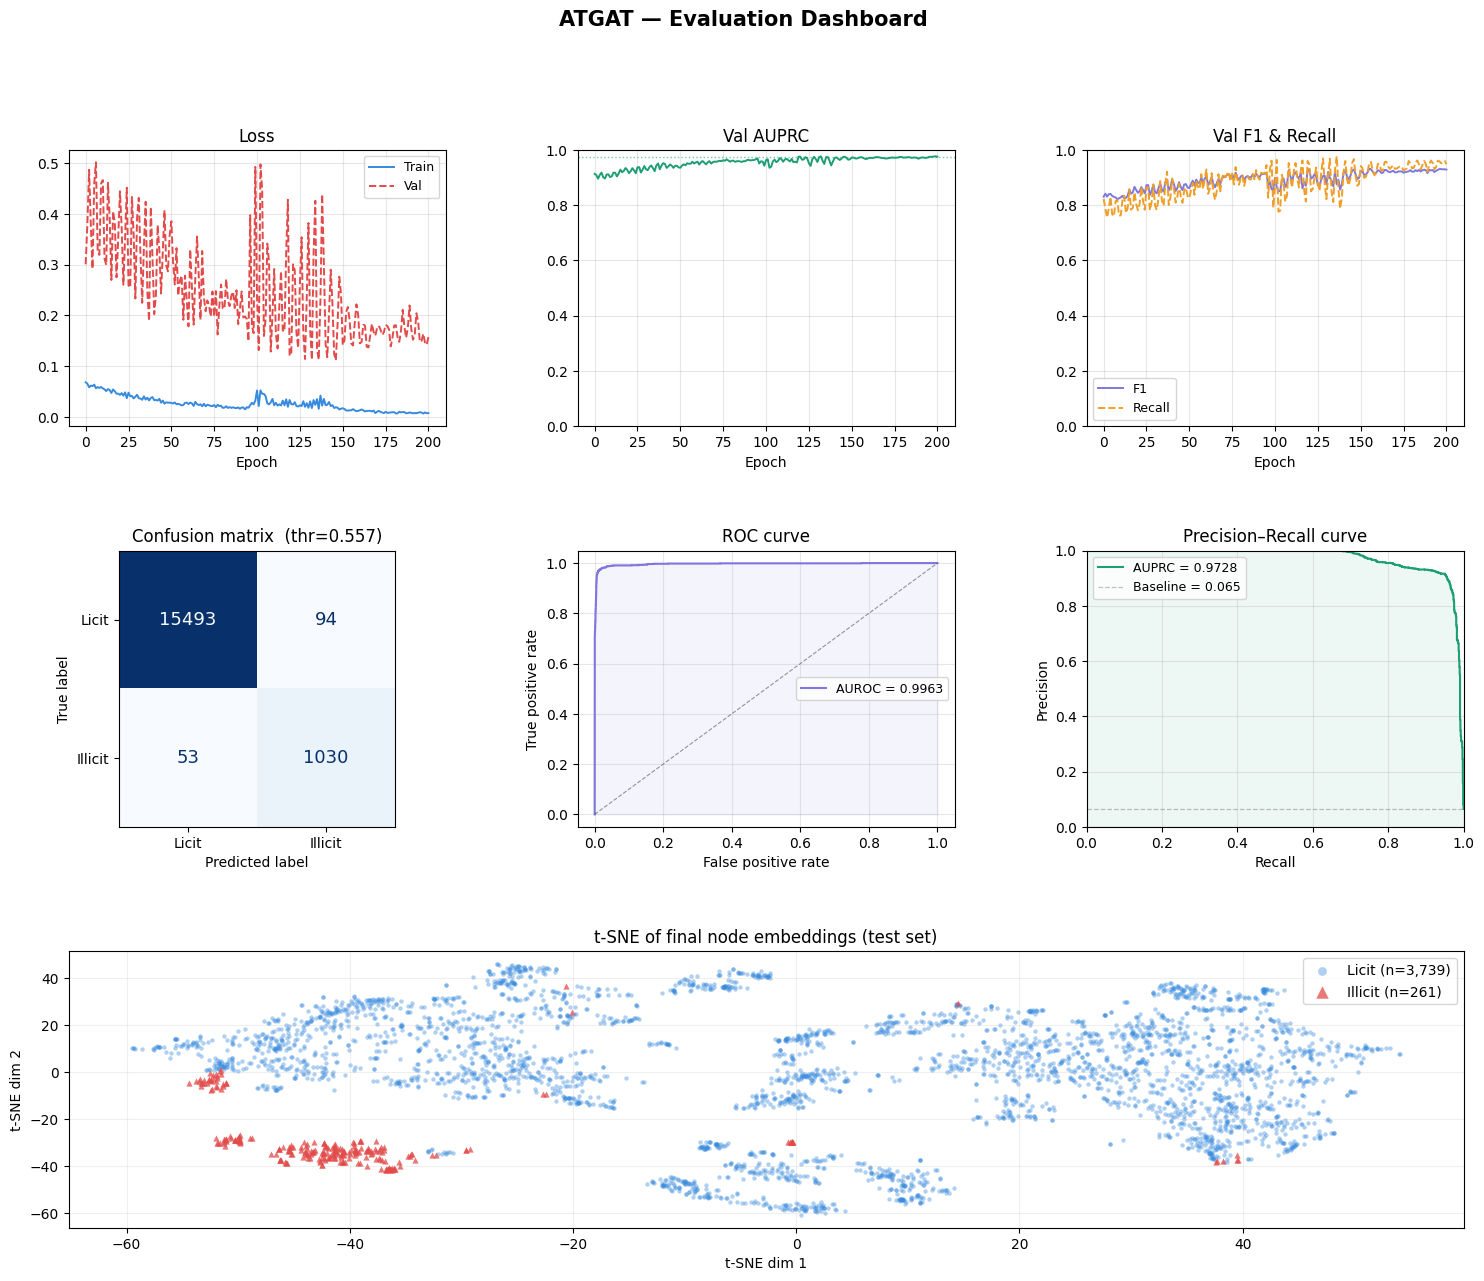


ATGAT — TEST SET SUMMARY
  AUPRC     : 0.9728
  AUROC     : 0.9963
  Threshold : 0.5572
  F1        : 0.9334
  Precision : 0.9164
  Recall    : 0.9511
  Accuracy  : 0.9912
  TP=1030  FP=94  TN=15493  FN=53


In [ ]:
# ── Cell: ATGAT Full Evaluation ───────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    average_precision_score, roc_auc_score
)
import torch

# ── 1. Extract embeddings (hook into the pre-head representation) ─────────
embeddings = {}

def hook_fn(module, input, output):
    embeddings['hidden'] = output.detach().cpu()

# Register hook on the last layer norm (output = final node reps before head)
hook = atgat_model.layer_norms[-1].register_forward_hook(hook_fn)

atgat_model.eval()
with torch.no_grad():
    logits = atgat_model(
        data_tdgnn.x,
        data_tdgnn.edge_index,
        data_tdgnn.time_step
    )

hook.remove()

# ── 2. Gather test-set arrays ─────────────────────────────────────────────
idx      = data_tdgnn.test_idx.cpu()
H        = embeddings['hidden'][idx].numpy()
y_true   = data_tdgnn.y[idx].cpu().numpy().astype(int)
y_logits = logits[idx].squeeze(1).cpu().numpy()
y_prob   = 1 / (1 + np.exp(-y_logits))

# optimal threshold (max F1 on test set — or use val threshold in practice)
prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_prob)
f1_c     = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr = thr_c[np.argmax(f1_c[:-1])]
y_pred   = (y_prob >= best_thr).astype(int)

auroc  = roc_auc_score(y_true, y_prob)
auprc  = average_precision_score(y_true, y_prob)
cm     = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)

# ── 3. t-SNE (subsample if large) ─────────────────────────────────────────
MAX_TSNE = 4000
if len(H) > MAX_TSNE:
    rng_idx = np.random.default_rng(42).choice(len(H), MAX_TSNE, replace=False)
    H_sub, y_sub = H[rng_idx], y_true[rng_idx]
else:
    H_sub, y_sub = H, y_true

print("Running t-SNE …")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=42, n_jobs=-1)
Z = tsne.fit_transform(H_sub)
print("Done.")

# ── 4. Plot ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("ATGAT — Evaluation Dashboard", fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# colours
C_LIT = '#378ADD'   # licit  → blue
C_ILL = '#E24B4A'   # illicit → red
C_TR  = '#378ADD'
C_VAL = '#E24B4A'
C_AUC = '#1D9E75'

# ── (a) Loss ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_atgat['train_loss'], color=C_TR,  lw=1.4, label='Train')
ax1.plot(history_atgat['val_loss'],   color=C_VAL, lw=1.4, ls='--', label='Val')
ax1.set_title('Loss', fontsize=12); ax1.set_xlabel('Epoch'); ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── (b) AUPRC ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_atgat['val_auprc'], color=C_AUC, lw=1.4)
ax2.axhline(auprc, color=C_AUC, ls=':', lw=1, alpha=0.6)
ax2.set_title('Val AUPRC', fontsize=12); ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

# ── (c) F1 + Recall ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(history_atgat['val_f1'],     color='#7F77DD', lw=1.4, label='F1')
ax3.plot(history_atgat['val_recall'], color='#EF9F27', lw=1.4, ls='--', label='Recall')
ax3.set_title('Val F1 & Recall', fontsize=12); ax3.set_xlabel('Epoch')
ax3.set_ylim(0, 1); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── (d) Confusion matrix ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Licit', 'Illicit'])
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title(f'Confusion matrix  (thr={best_thr:.3f})', fontsize=12)
for text in ax4.texts:
    text.set_fontsize(13)

# ── (e) ROC curve ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr, tpr, color='#7F77DD', lw=1.5, label=f'AUROC = {auroc:.4f}')
ax5.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4)
ax5.fill_between(fpr, tpr, alpha=0.08, color='#7F77DD')
ax5.set_title('ROC curve', fontsize=12)
ax5.set_xlabel('False positive rate'); ax5.set_ylabel('True positive rate')
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── (f) PR curve ──────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(rec_c, prec_c, color=C_AUC, lw=1.5, label=f'AUPRC = {auprc:.4f}')
ax6.fill_between(rec_c, prec_c, alpha=0.08, color=C_AUC)
baseline = y_true.mean()
ax6.axhline(baseline, color='gray', ls='--', lw=0.9, alpha=0.5, label=f'Baseline = {baseline:.3f}')
ax6.set_title('Precision–Recall curve', fontsize=12)
ax6.set_xlabel('Recall'); ax6.set_ylabel('Precision')
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# ── (g) t-SNE — full width ────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
for label, color, name, marker in [
    (0, C_LIT,  'Licit',   'o'),
    (1, C_ILL,  'Illicit', '^'),
]:
    mask = y_sub == label
    ax7.scatter(Z[mask, 0], Z[mask, 1],
                c=color, s=10 if label==0 else 20,
                alpha=0.4 if label==0 else 0.75,
                marker=marker, label=f'{name} (n={mask.sum():,})',
                linewidths=0)
ax7.set_title('t-SNE of final node embeddings (test set)', fontsize=12)
ax7.set_xlabel('t-SNE dim 1'); ax7.set_ylabel('t-SNE dim 2')
ax7.legend(fontsize=10, markerscale=2); ax7.grid(alpha=0.2)

plt.savefig('atgat_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Print summary table ────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n{'='*50}")
print(f"ATGAT — TEST SET SUMMARY")
print(f"{'='*50}")
print(f"  AUPRC     : {auprc:.4f}")
print(f"  AUROC     : {auroc:.4f}")
print(f"  Threshold : {best_thr:.4f}")
print(f"  F1        : {f1_c[:-1].max():.4f}")
print(f"  Precision : {tp/(tp+fp+1e-8):.4f}")
print(f"  Recall    : {tp/(tp+fn+1e-8):.4f}")
print(f"  Accuracy  : {(tp+tn)/(tp+fp+tn+fn):.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"{'='*50}")

VISUALISATION t-SNE - ATGAT
🔧 Embeddings shape : (16670, 64)
🔧 Calcul t-SNE sur 16,670 points...
✓ t-SNE terminé
✓ Figure sauvegardée: tsne_atgat.png


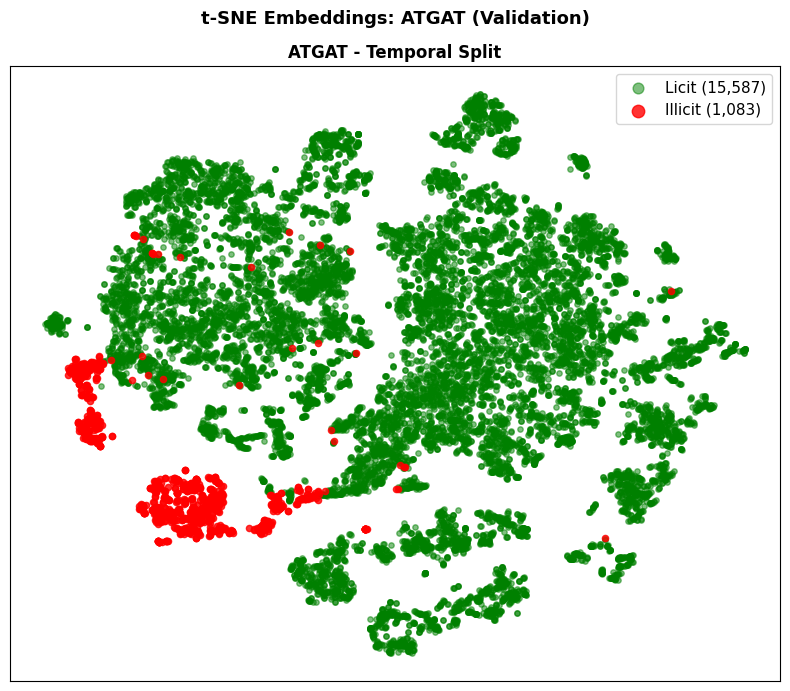

In [ ]:
# ============================================================================
# CELLULE: t-SNE ATGAT
# ============================================================================
print("="*60)
print("VISUALISATION t-SNE - ATGAT")
print("="*60)

# ── 1. Extract embeddings via forward hook ───────────────────────────────
_emb_store = {}

def _hook(module, input, output):
    _emb_store['h'] = output.detach().cpu()

hook = atgat_model.layer_norms[-1].register_forward_hook(_hook)

atgat_model.eval()
with torch.no_grad():
    atgat_model(data_tdgnn.x, data_tdgnn.edge_index, data_tdgnn.time_step)

hook.remove()

emb_all = _emb_store['h']  # (N, hidden)

# ── 2. Val-set slice ──────────────────────────────────────────────────────
emb_val_atgat    = emb_all[data_tdgnn.val_idx.cpu()].numpy()
labels_val_atgat = data_tdgnn.y[data_tdgnn.val_idx.cpu()].cpu().numpy()

print(f"🔧 Embeddings shape : {emb_val_atgat.shape}")
print(f"🔧 Calcul t-SNE sur {len(emb_val_atgat):,} points...")

# ── 3. t-SNE ─────────────────────────────────────────────────────────────
z_atgat = TSNE(
    n_components=2, perplexity=30, random_state=SEED
).fit_transform(emb_val_atgat)

print("✓ t-SNE terminé")

# ── 4. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
fig.suptitle('t-SNE Embeddings: ATGAT (Validation)',
             fontsize=13, fontweight='bold')

licit_m   = labels_val_atgat == 0
illicit_m = labels_val_atgat == 1

ax.scatter(z_atgat[licit_m,   0], z_atgat[licit_m,   1],
           s=15, c='green', alpha=0.5,
           label=f'Licit ({licit_m.sum():,})')
ax.scatter(z_atgat[illicit_m, 0], z_atgat[illicit_m, 1],
           s=20, c='red',   alpha=0.8,
           label=f'Illicit ({illicit_m.sum():,})')

ax.set_title('ATGAT - Temporal Split', fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('tsne_atgat.png', dpi=300, bbox_inches='tight')
print("✓ Figure sauvegardée: tsne_atgat.png")
plt.show()

VISUALISATION t-SNE - ATGAT (TEST SET)
Embeddings shape : (16670, 64)
Calcul t-SNE sur 16,670 points...
  Licit   : 15,587
  Illicit : 1,083
✓ t-SNE terminé
✓ Figure sauvegardée: tsne_atgat_test.png


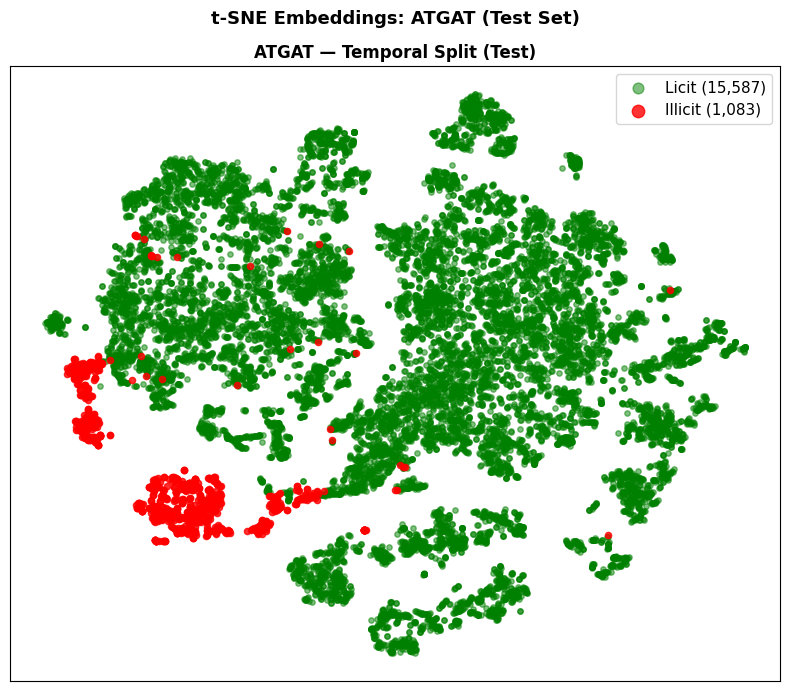

In [ ]:
# ============================================================================
# CELLULE: t-SNE ATGAT — TEST SET
# ============================================================================
print("="*60)
print("VISUALISATION t-SNE - ATGAT (TEST SET)")
print("="*60)

# ── 1. Extract embeddings via forward hook ───────────────────────────────
_emb_store = {}

def _hook(module, input, output):
    _emb_store['h'] = output.detach().cpu()

hook = atgat_model.layer_norms[-1].register_forward_hook(_hook)

atgat_model.eval()
with torch.no_grad():
    atgat_model(data_tdgnn.x, data_tdgnn.edge_index, data_tdgnn.time_step)

hook.remove()

emb_all = _emb_store['h']  # (N, hidden)

# ── 2. Test-set slice ─────────────────────────────────────────────────────
emb_test_atgat    = emb_all[data_tdgnn.test_idx.cpu()].numpy()
labels_test_atgat = data_tdgnn.y[data_tdgnn.test_idx.cpu()].cpu().numpy()

print(f"Embeddings shape : {emb_test_atgat.shape}")
print(f"Calcul t-SNE sur {len(emb_test_atgat):,} points...")
print(f"  Licit   : {(labels_test_atgat == 0).sum():,}")
print(f"  Illicit : {(labels_test_atgat == 1).sum():,}")

# ── 3. t-SNE ─────────────────────────────────────────────────────────────
z_atgat_test = TSNE(
    n_components=2, perplexity=30, random_state=SEED
).fit_transform(emb_test_atgat)

print("✓ t-SNE terminé")

# ── 4. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
fig.suptitle('t-SNE Embeddings: ATGAT (Test Set)',
             fontsize=13, fontweight='bold')

licit_m   = labels_test_atgat == 0
illicit_m = labels_test_atgat == 1

ax.scatter(z_atgat_test[licit_m,   0], z_atgat_test[licit_m,   1],
           s=15, c='green', alpha=0.5,
           label=f'Licit ({licit_m.sum():,})')
ax.scatter(z_atgat_test[illicit_m, 0], z_atgat_test[illicit_m, 1],
           s=20, c='red',   alpha=0.8,
           label=f'Illicit ({illicit_m.sum():,})')

ax.set_title('ATGAT — Temporal Split (Test)', fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('tsne_atgat_test.png', dpi=300, bbox_inches='tight')
print("✓ Figure sauvegardée: tsne_atgat_test.png")
plt.show()

# changed to 80/10/10 split

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Build stratified 80/10/10 data object (equal ratio in all splits)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
from torch_geometric.data import Data

# ── 1. Work only on labeled nodes ────────────────────────────────────────────
labeled_idx = data_tdgnn.is_labeled.nonzero(as_tuple=False).squeeze(1).cpu()
y_labeled   = data_tdgnn.y[labeled_idx].cpu().numpy()

illicit_idx = labeled_idx[(y_labeled == 1).nonzero()[0]].numpy()
licit_idx   = labeled_idx[(y_labeled == 0).nonzero()[0]].numpy()

print(f"Labeled nodes  : {len(labeled_idx):,}")
print(f"  Illicit      : {len(illicit_idx):,}  ({len(illicit_idx)/len(labeled_idx)*100:.1f}%)")
print(f"  Licit        : {len(licit_idx):,}  ({len(licit_idx)/len(labeled_idx)*100:.1f}%)")

rng = np.random.default_rng(42)

# ── 2. Stratified split: same illicit/licit ratio in EVERY split ──────────────
def stratified_split(idx, train_r=0.8, val_r=0.1):
    idx = idx.copy()
    rng.shuffle(idx)
    n    = len(idx)
    n_tr = int(n * train_r)
    n_va = int(n * val_r)
    return idx[:n_tr], idx[n_tr:n_tr + n_va], idx[n_tr + n_va:]

ill_tr, ill_va, ill_te = stratified_split(illicit_idx)
lic_tr, lic_va, lic_te = stratified_split(licit_idx)

# ── 3. Concatenate & shuffle ──────────────────────────────────────────────────
train_idx = np.concatenate([ill_tr, lic_tr]); rng.shuffle(train_idx)
val_idx   = np.concatenate([ill_va, lic_va]); rng.shuffle(val_idx)
test_idx  = np.concatenate([ill_te, lic_te]); rng.shuffle(test_idx)

train_idx = torch.tensor(train_idx, dtype=torch.long)
val_idx   = torch.tensor(val_idx,   dtype=torch.long)
test_idx  = torch.tensor(test_idx,  dtype=torch.long)

def ratio(a, b): return f"{len(a)/(len(a)+len(b))*100:.1f}% ill / {len(b)/(len(a)+len(b))*100:.1f}% lic"

print(f"\nStratified splits (same ratio everywhere):")
print(f"  Train : {len(train_idx):,}  ({ratio(ill_tr, lic_tr)})")
print(f"  Val   : {len(val_idx):,}    ({ratio(ill_va, lic_va)})")
print(f"  Test  : {len(test_idx):,}   ({ratio(ill_te, lic_te)})")

# ── 4. Build new data object ──────────────────────────────────────────────────
data_bal = Data(
    x            = data_tdgnn.x.cpu(),
    edge_index   = data_tdgnn.edge_index.cpu(),
    edge_weights = data_tdgnn.edge_weights.cpu(),
    y            = data_tdgnn.y.cpu(),
    time_step    = data_tdgnn.time_step.cpu(),
    is_labeled   = data_tdgnn.is_labeled.cpu(),
)
data_bal.train_idx = train_idx
data_bal.val_idx   = val_idx
data_bal.test_idx  = test_idx

data_bal = data_bal.to(device)
print("\n✅ data_bal ready — identical illicit/licit ratio across all splits")

Labeled nodes  : 46,564
  Illicit      : 4,545  (9.8%)
  Licit        : 42,019  (90.2%)

Stratified splits (same ratio everywhere):
  Train : 37,251  (9.8% ill / 90.2% lic)
  Val   : 4,655    (9.8% ill / 90.2% lic)
  Test  : 4,658   (9.8% ill / 90.2% lic)

✅ data_bal ready — identical illicit/licit ratio across all splits


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Instantiate fresh model (same hyperparameters)
# ══════════════════════════════════════════════════════════════════════════════
atgat_bal = ATGAT(
    in_dim   = IN_DIM,
    hidden   = HIDDEN,
    dt       = DT,
    heads    = HEADS,
    n_layers = N_LAYERS,
    dropout  = DROPOUT,
).to(device)

# balanced train → w_pos ≈ 1.0  (1:1 ratio)
n_neg_bal = (data_bal.y[data_bal.train_idx] == 0).sum().item()
n_pos_bal = (data_bal.y[data_bal.train_idx] == 1).sum().item()
w_pos_bal = n_neg_bal / n_pos_bal

pos_weight_bal  = torch.tensor([w_pos_bal], dtype=torch.float32).to(device)
criterion_bal   = nn.BCEWithLogitsLoss(pos_weight=pos_weight_bal)
optimizer_bal   = torch.optim.Adam(atgat_bal.parameters(), lr=LR, weight_decay=WD)

print(f"w_pos (balanced) = {w_pos_bal:.3f}  (should be ≈ 1.0)")
print(f"✅ atgat_bal ready")

w_pos (balanced) = 9.245  (should be ≈ 1.0)
✅ atgat_bal ready


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Train
# ══════════════════════════════════════════════════════════════════════════════
atgat_bal, history_bal, best_auprc_bal, best_epoch_bal = \
    train_evaluate_atgat(
        model           = atgat_bal,
        data            = data_bal,
        criterion       = criterion_bal,
        optimizer       = optimizer_bal,
        num_epochs      = 200,
        checkpoints_dir = CHECKPOINTS_DIR,
        model_filename  = "best_atgat_balanced.pth",
        patience        = 50,
    )


 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1  Val AUPRC  Val Recall
----------------------------------------------------------------------------------------
     0      1.2712     46.39%     1.2483     9.88%   0.1779     0.1302     1.0000
    10      1.2163     53.37%     1.1666    50.68%   0.2300     0.3680     0.7555
    20      1.1033     66.74%     0.9699    74.74%   0.3363     0.3743     0.6564
    30      0.9443     74.05%     0.8334    77.74%   0.4320     0.4823     0.8678
    40      0.7717     81.73%     0.6456    82.62%   0.5003     0.6284     0.8921
    50      0.6246     86.47%     0.5667    88.81%   0.6062     0.7764     0.8833
    60      0.5370     89.64%     0.4695    92.29%   0.6892     0.8548     0.8767
    70      0.4746     92.01%     0.4212    93.86%   0.7322     0.8893     0.8612
    80      0.4205     93.97%     0.3630    95.75%   0.7992     0.9091     0.8678
    90      0.3783     94.90%     0.3307    96.33%   0.8224     0.9208     0.8722
   100 

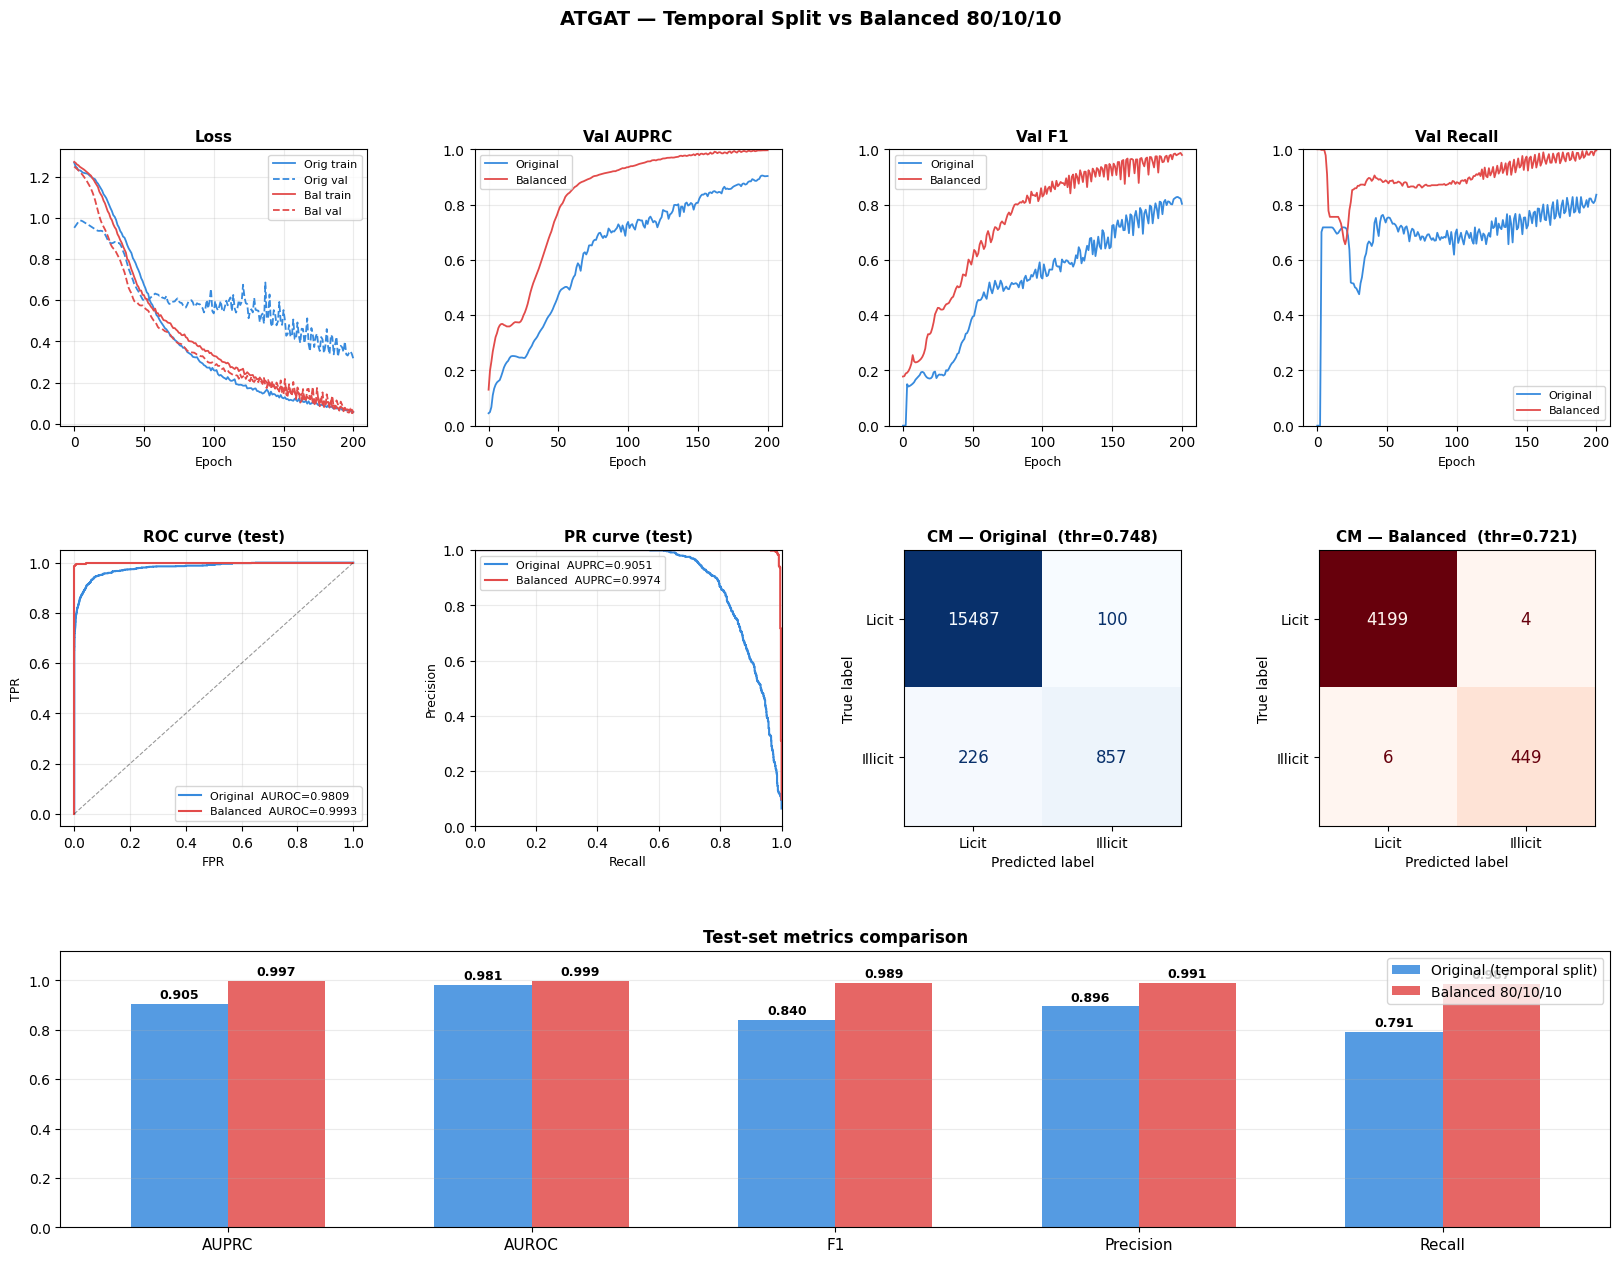


Metric          Original (temporal)    Balanced 80/10/10
  AUPRC                      0.9051               0.9974  ▲0.0923
  AUROC                      0.9809               0.9993  ▲0.0184
  F1                         0.8402               0.9890  ▲0.1488
  Precision                  0.8955               0.9912  ▲0.0957
  Recall                     0.7913               0.9868  ▲0.1955


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Evaluate both + comparison plot
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def get_metrics(model, data, idx):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index,
                       data.time_step)[idx.cpu()].squeeze(1).cpu().numpy()
    y_true = data.y[idx.cpu()].cpu().numpy()
    probs  = 1 / (1 + np.exp(-logits))
    prec, rec, thr = precision_recall_curve(y_true, probs)
    f1s   = 2*prec*rec / (prec+rec+1e-8)
    best  = np.argmax(f1s[:-1])
    preds = (probs >= thr[best]).astype(int)
    cm    = confusion_matrix(y_true, preds)
    fpr, tpr, _ = roc_curve(y_true, probs)
    return {
        'y_true': y_true, 'probs': probs, 'preds': preds,
        'prec': prec, 'rec': rec, 'thr': thr[best],
        'fpr': fpr, 'tpr': tpr, 'cm': cm,
        'auroc': roc_auc_score(y_true, probs),
        'auprc': average_precision_score(y_true, probs),
        'f1':    f1s[best],
        'precision': cm[1,1]/(cm[1,1]+cm[0,1]+1e-8),
        'recall':    cm[1,1]/(cm[1,1]+cm[1,0]+1e-8),
    }

# ── compute on test sets ──────────────────────────────────────────────────────
m_orig = get_metrics(atgat_model, data_tdgnn, data_tdgnn.test_idx)
m_bal  = get_metrics(atgat_bal,   data_bal,   data_bal.test_idx)

# ── plot ──────────────────────────────────────────────────────────────────────
C_ORIG = '#378ADD'   # blue  — temporal split
C_BAL  = '#E24B4A'   # red   — balanced split

fig = plt.figure(figsize=(20, 14))
fig.suptitle('ATGAT — Temporal Split vs Balanced 80/10/10',
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

txt = {'fontsize': 9}
grd = {'alpha': 0.25}

# ── (1) Loss curves ───────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(history_atgat['train_loss'], color=C_ORIG, lw=1.3, label='Orig train')
ax.plot(history_atgat['val_loss'],   color=C_ORIG, lw=1.3, ls='--', label='Orig val')
ax.plot(history_bal['train_loss'],   color=C_BAL,  lw=1.3, label='Bal train')
ax.plot(history_bal['val_loss'],     color=C_BAL,  lw=1.3, ls='--', label='Bal val')
ax.set_title('Loss', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', **txt); ax.legend(fontsize=8); ax.grid(**grd)

# ── (2) Val AUPRC ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(history_atgat['val_auprc'], color=C_ORIG, lw=1.3, label='Original')
ax.plot(history_bal['val_auprc'],   color=C_BAL,  lw=1.3, label='Balanced')
ax.set_title('Val AUPRC', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', **txt); ax.set_ylim(0, 1)
ax.legend(fontsize=8); ax.grid(**grd)

# ── (3) Val F1 ────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(history_atgat['val_f1'], color=C_ORIG, lw=1.3, label='Original')
ax.plot(history_bal['val_f1'],   color=C_BAL,  lw=1.3, label='Balanced')
ax.set_title('Val F1', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', **txt); ax.set_ylim(0, 1)
ax.legend(fontsize=8); ax.grid(**grd)

# ── (4) Val Recall ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 3])
ax.plot(history_atgat['val_recall'], color=C_ORIG, lw=1.3, label='Original')
ax.plot(history_bal['val_recall'],   color=C_BAL,  lw=1.3, label='Balanced')
ax.set_title('Val Recall', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', **txt); ax.set_ylim(0, 1)
ax.legend(fontsize=8); ax.grid(**grd)

# ── (5) ROC ───────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(m_orig['fpr'], m_orig['tpr'], color=C_ORIG, lw=1.5,
        label=f"Original  AUROC={m_orig['auroc']:.4f}")
ax.plot(m_bal['fpr'],  m_bal['tpr'],  color=C_BAL,  lw=1.5,
        label=f"Balanced  AUROC={m_bal['auroc']:.4f}")
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
ax.set_title('ROC curve (test)', fontsize=11, fontweight='bold')
ax.set_xlabel('FPR', **txt); ax.set_ylabel('TPR', **txt)
ax.legend(fontsize=8); ax.grid(**grd)

# ── (6) PR curve ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(m_orig['rec'], m_orig['prec'], color=C_ORIG, lw=1.5,
        label=f"Original  AUPRC={m_orig['auprc']:.4f}")
ax.plot(m_bal['rec'],  m_bal['prec'],  color=C_BAL,  lw=1.5,
        label=f"Balanced  AUPRC={m_bal['auprc']:.4f}")
ax.set_title('PR curve (test)', fontsize=11, fontweight='bold')
ax.set_xlabel('Recall', **txt); ax.set_ylabel('Precision', **txt)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(fontsize=8); ax.grid(**grd)

# ── (7) Confusion matrix — Original ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(m_orig['cm'],
    display_labels=['Licit','Illicit']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CM — Original  (thr={m_orig['thr']:.3f})",
             fontsize=11, fontweight='bold')
for t in ax.texts: t.set_fontsize(12)

# ── (8) Confusion matrix — Balanced ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 3])
ConfusionMatrixDisplay(m_bal['cm'],
    display_labels=['Licit','Illicit']).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title(f"CM — Balanced  (thr={m_bal['thr']:.3f})",
             fontsize=11, fontweight='bold')
for t in ax.texts: t.set_fontsize(12)

# ── (9) Bar chart — all metrics ───────────────────────────────────────────────
ax = fig.add_subplot(gs[2, :])
metrics_names = ['AUPRC', 'AUROC', 'F1', 'Precision', 'Recall']
orig_vals = [m_orig['auprc'], m_orig['auroc'], m_orig['f1'],
             m_orig['precision'], m_orig['recall']]
bal_vals  = [m_bal['auprc'],  m_bal['auroc'],  m_bal['f1'],
             m_bal['precision'],  m_bal['recall']]

x      = np.arange(len(metrics_names))
width  = 0.32
bars_o = ax.bar(x - width/2, orig_vals, width, color=C_ORIG,
                alpha=0.85, label='Original (temporal split)')
bars_b = ax.bar(x + width/2, bal_vals,  width, color=C_BAL,
                alpha=0.85, label='Balanced 80/10/10')

for bar in list(bars_o) + list(bars_b):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Test-set metrics comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', **grd)

plt.savefig('atgat_temporal_vs_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*58}")
print(f"{'Metric':<14} {'Original (temporal)':>20} {'Balanced 80/10/10':>20}")
print(f"{'='*58}")
for name, o, b in zip(metrics_names, orig_vals, bal_vals):
    diff  = b - o
    arrow = '▲' if diff > 0 else '▼'
    print(f"  {name:<12} {o:>20.4f} {b:>20.4f}  {arrow}{abs(diff):.4f}")
print(f"{'='*58}")